**Name: Abeer Fatima**

**Roll no: 22F-BSAI-38**

**Department: BSAI (A1)**

**Subject: Deep Learning**

**Teacher: Sir Hamza**

# **Import Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/dataset.csv")

In [ ]:
df.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,Unnamed: 83,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,NaN,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,NaN,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,NaN,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,NaN,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,NaN,0


In [ ]:
df.shape

(91713, 85)

# **Data Cleaning & Preprocessing**

In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_id,0
hospital_id,0
age,4228
bmi,3429
...,...
solid_tumor_with_metastasis,715
apache_3j_bodysystem,1662
apache_2_bodysystem,1662
Unnamed: 83,91713


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 85 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   encounter_id                   91713 non-null  int64  
 1   patient_id                     91713 non-null  int64  
 2   hospital_id                    91713 non-null  int64  
 3   age                            87485 non-null  float64
 4   bmi                            88284 non-null  float64
 5   elective_surgery               91713 non-null  int64  
 6   ethnicity                      90318 non-null  object 
 7   gender                         91688 non-null  object 
 8   height                         90379 non-null  float64
 9   icu_admit_source               91601 non-null  object 
 10  icu_id                         91713 non-null  int64  
 11  icu_stay_type                  91713 non-null  object 
 12  icu_type                       91713 non-null 

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# check if dataset contain any (  ,) ,@,!? or any of other special characters

import re

def contains_special_characters(df):
  """
  Checks if the DataFrame contains any special characters like (, ), @, !, ?.

  Args:
    df: The Pandas DataFrame to check.

  Returns:
    True if any special characters are found, False otherwise.
  """

  for column in df.columns:
    if df[column].dtype == object:  # Check only string columns
      for value in df[column]:
        if re.search(r"[^\w\s]", str(value)):  # Checks for any non-alphanumeric and non-whitespace characters
          return True
  return False

if contains_special_characters(df):
  print("Dataset contains special characters.")
else:
  print("Dataset does not contain special characters.")

Dataset contains special characters.


In [ ]:
# remove special characters from dataset

def remove_special_characters(df):
  """
  Removes special characters from string columns in a DataFrame.

  Args:
    df: The Pandas DataFrame to modify.

  Returns:
    The DataFrame with special characters removed from string columns.
  """

  for column in df.columns:
    if df[column].dtype == object:  # Check only string columns
      df[column] = df[column].str.replace('[^A-Za-z0-9\s]+', '', regex=True)
  return df

df = remove_special_characters(df)

if contains_special_characters(df):
  print("Dataset still contains special characters.")
else:
  print("Special characters have been removed from the dataset.")

<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6048/1775759669.py:16: SyntaxWarning: invalid escape sequence '\s'
  df[column] = df[column].str.replace('[^A-Za-z0-9\s]+', '', regex=True)


Special characters have been removed from the dataset.


In [ ]:
# check if dataset contain any special character in dataset

def contains_special_characters(df):
  """
  Checks if the DataFrame contains any special characters like (, ), @, !, ?.

  Args:
    df: The Pandas DataFrame to check.

  Returns:
    True if any special characters are found, False otherwise.
  """

  for column in df.columns:
    if df[column].dtype == object:  # Check only string columns
      for value in df[column]:
        if re.search(r"[^\w\s]", str(value)):  # Checks for any non-alphanumeric and non-whitespace characters
          return True
  return False

if contains_special_characters(df):
  print("Dataset contains special characters.")
else:
  print("Dataset does not contain special characters.")

Dataset does not contain special characters.


In [ ]:
# check if there is any special character in numeric column

def has_special_characters_in_numeric_column(df):
  """
  Checks if any numeric column in the DataFrame contains special characters.

  Args:
    df: The Pandas DataFrame to check.

  Returns:
    True if special characters are found in any numeric column, False otherwise.
  """

  for column in df.select_dtypes(include=np.number):
    for value in df[column]:
      if isinstance(value, (int, float)):
          continue
      if re.search(r"[^\d\.]", str(value)):  # Check for non-digit and non-decimal point characters
        return True
  return False

if has_special_characters_in_numeric_column(df):
  print("Numeric columns contain special characters.")
else:
  print("Numeric columns do not contain special characters.")

Numeric columns do not contain special characters.


Top 20 columns with most outliers:

                           column  outliers_count
70              diabetes_mellitus           20492
15               gcs_motor_apache           18852
17              gcs_verbal_apache           18681
12          apache_post_operative           18444
5                elective_surgery           16851
8                pre_icu_los_days           15815
19               intubated_apache           13761
67       apache_4a_icu_death_prob           13377
66  apache_4a_hospital_death_prob           11372
36                    d1_spo2_max            9262
22                    temp_apache            8762
14                gcs_eyes_apache            8274
43                    d1_temp_min            6216
37                    d1_spo2_min            5973
42                    d1_temp_max            5572
62                 d1_glucose_max            5390
35                d1_resprate_min            4754
34                d1_resprate_max            4638
11            

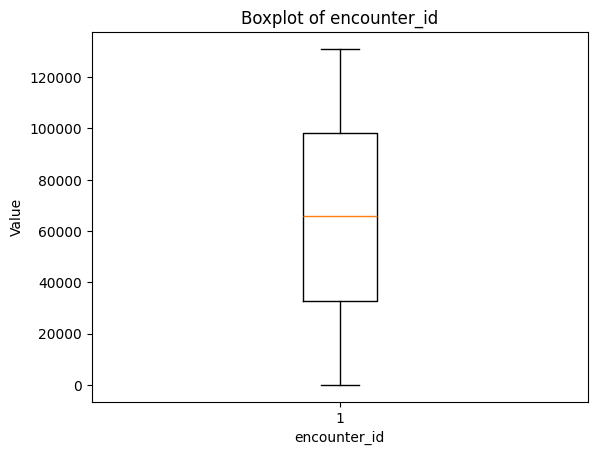

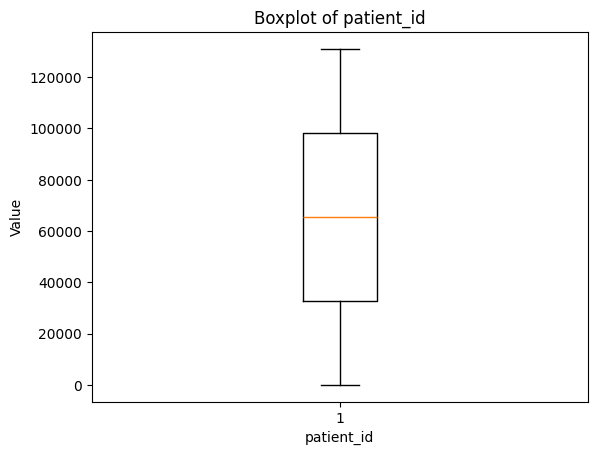

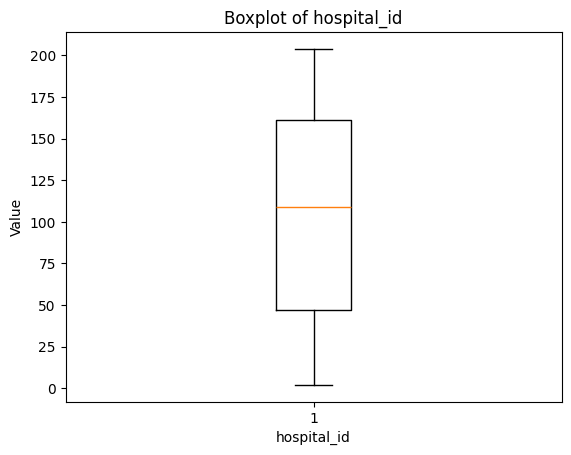

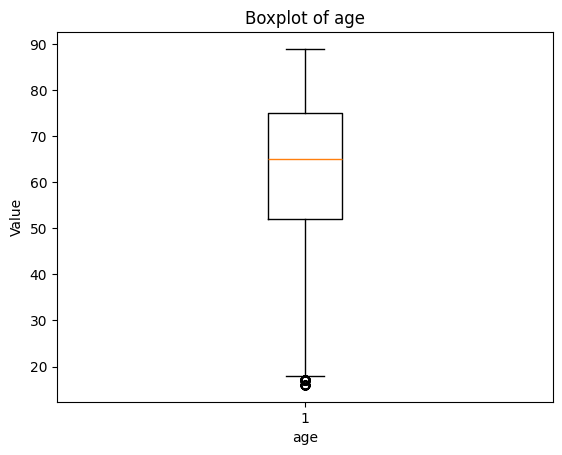

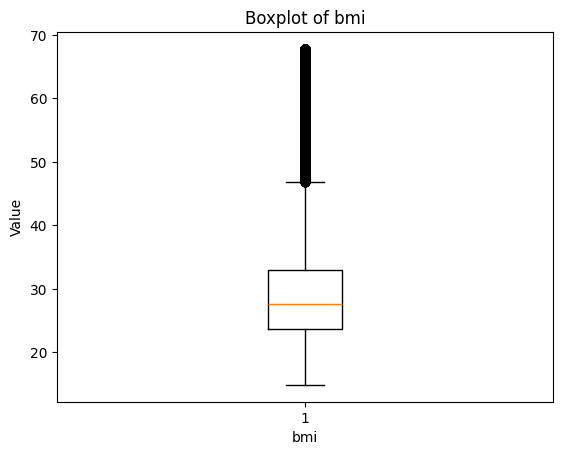

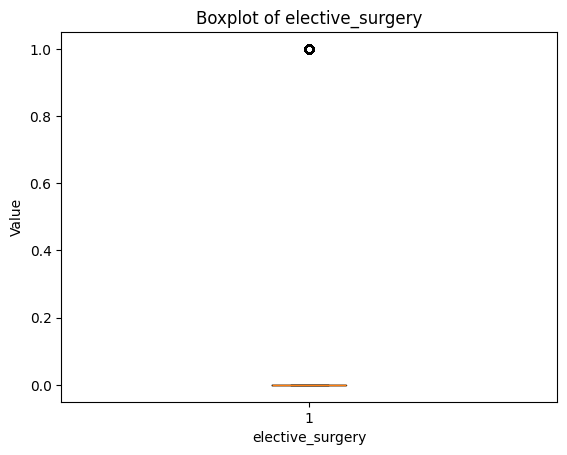

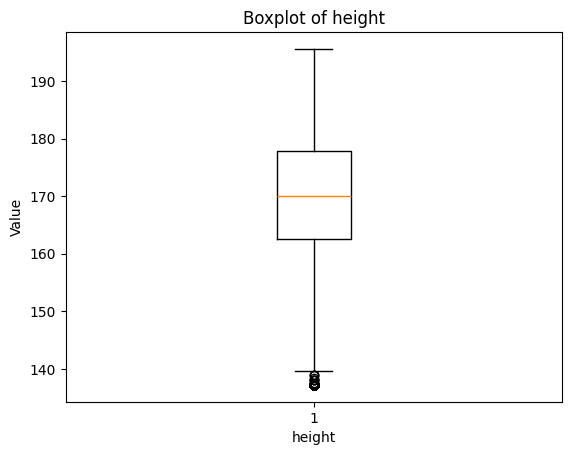

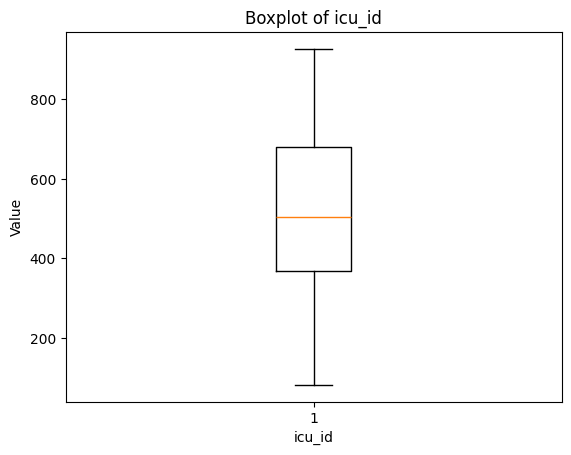

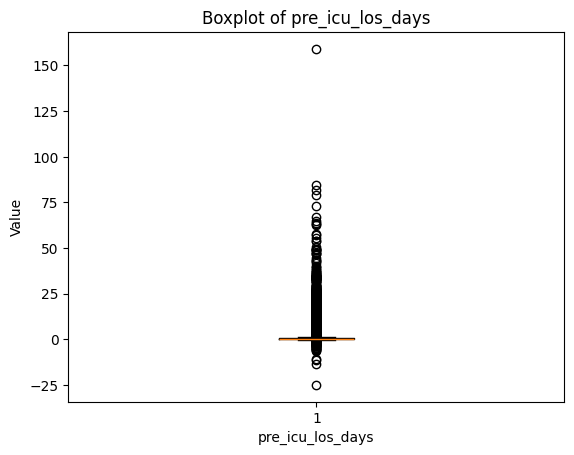

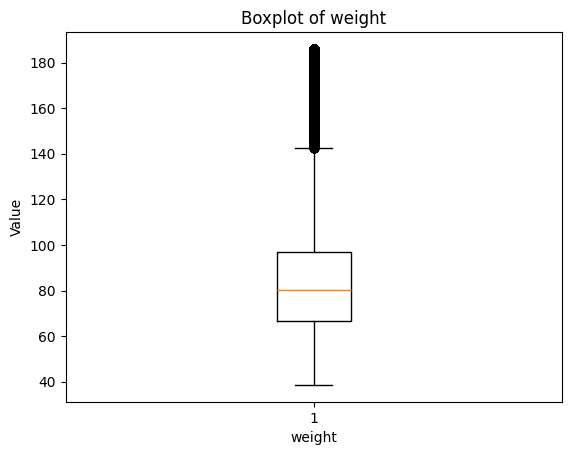

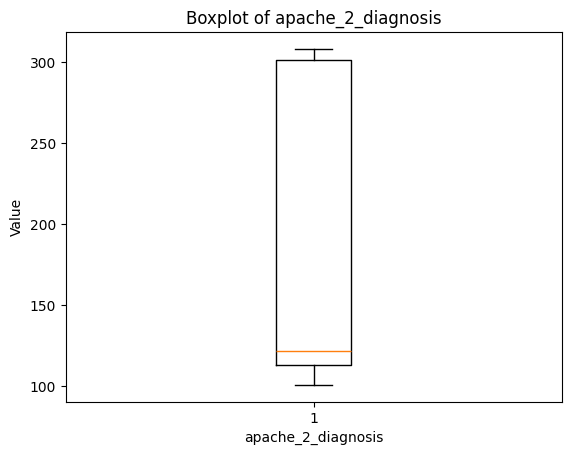

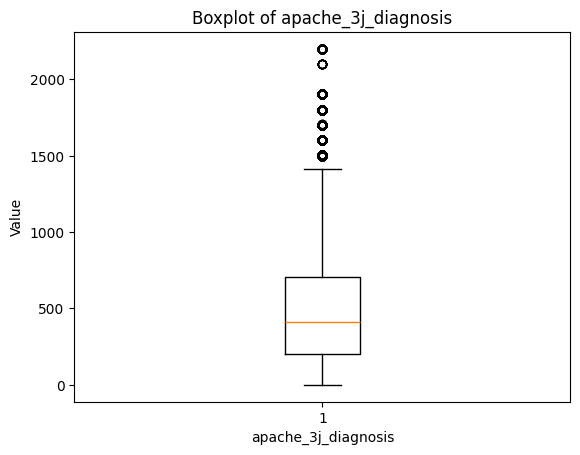

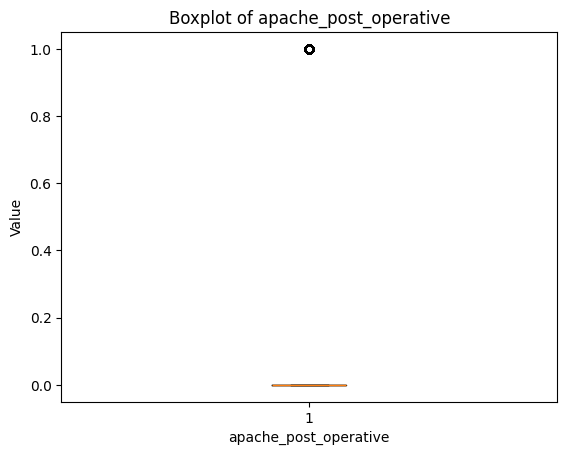

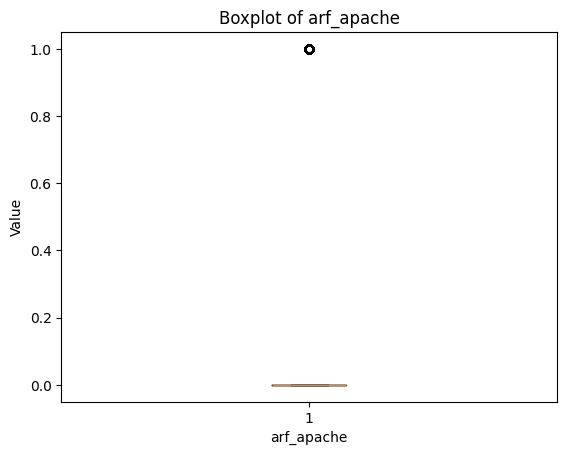

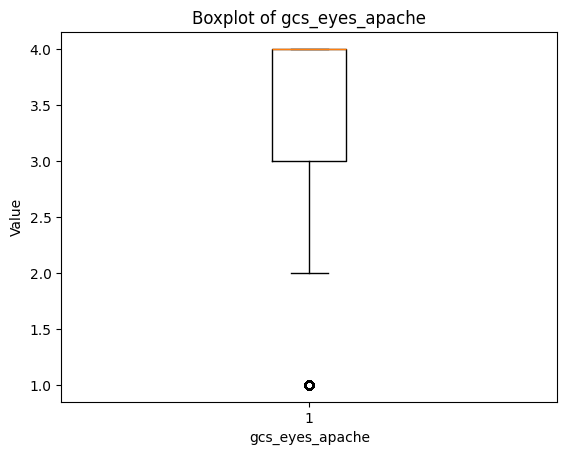

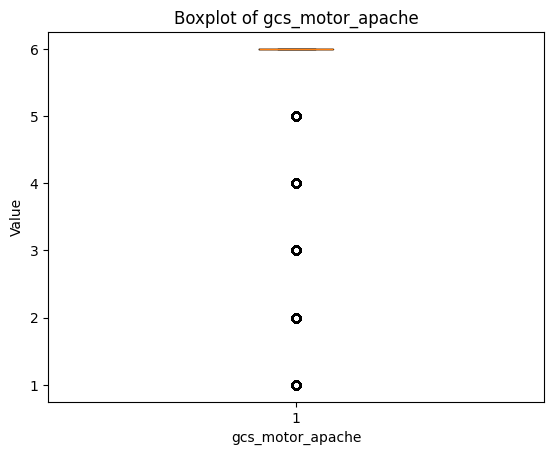

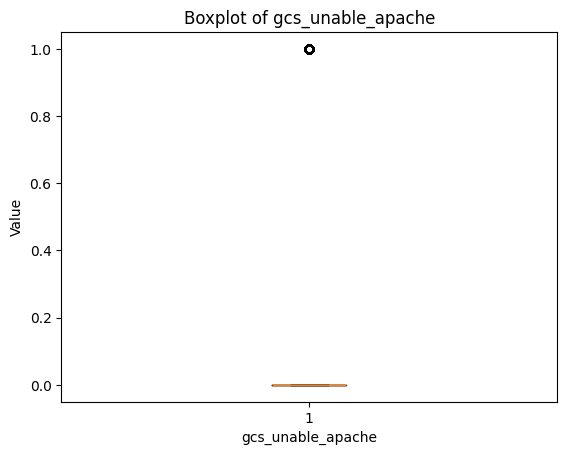

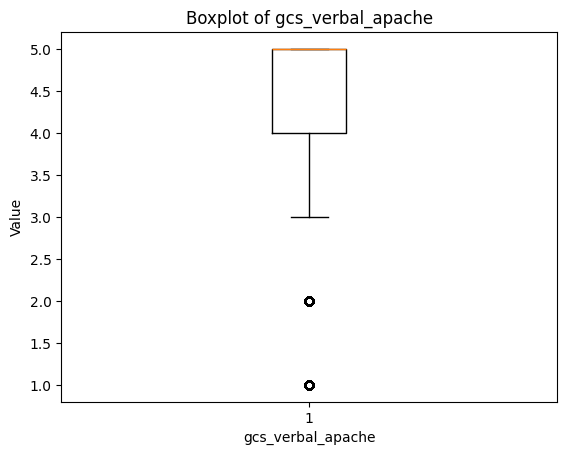

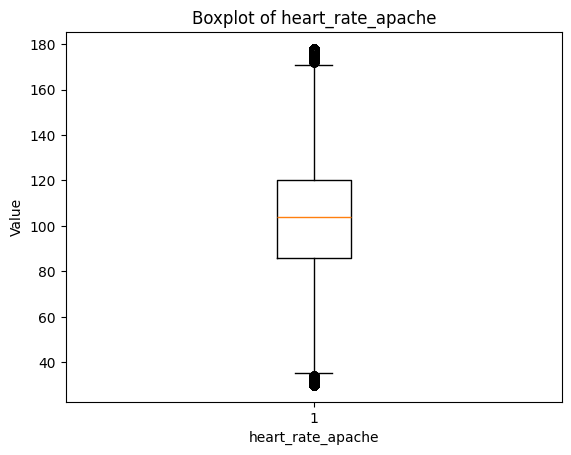

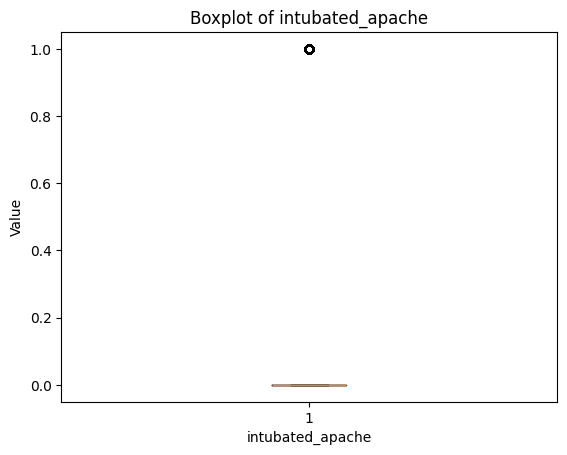

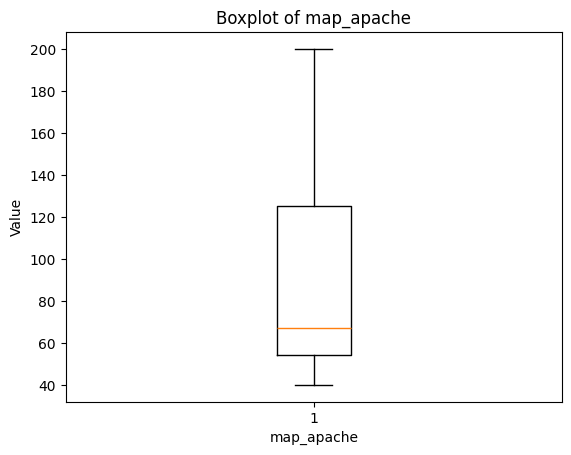

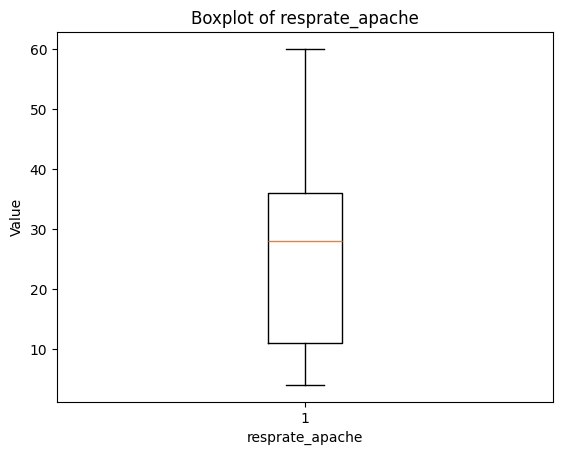

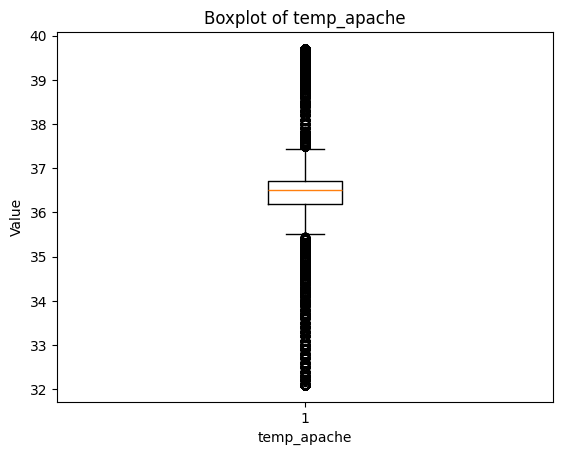

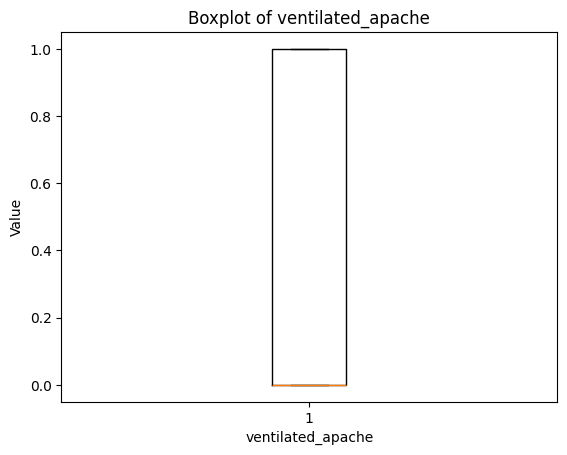

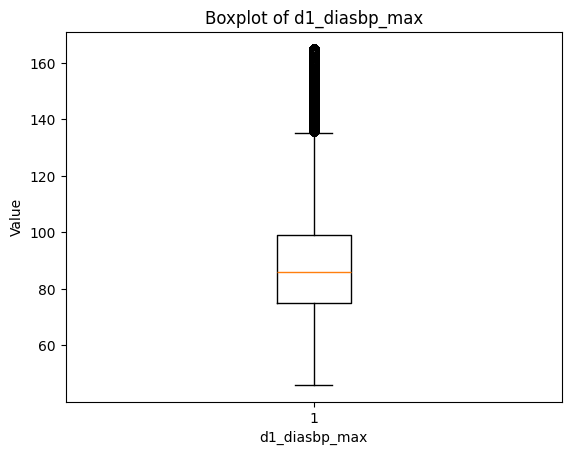

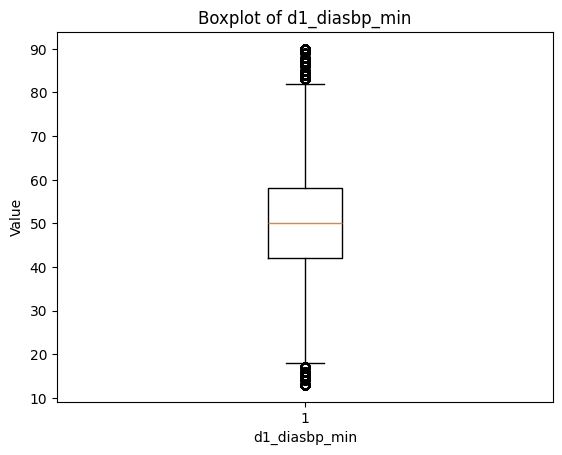

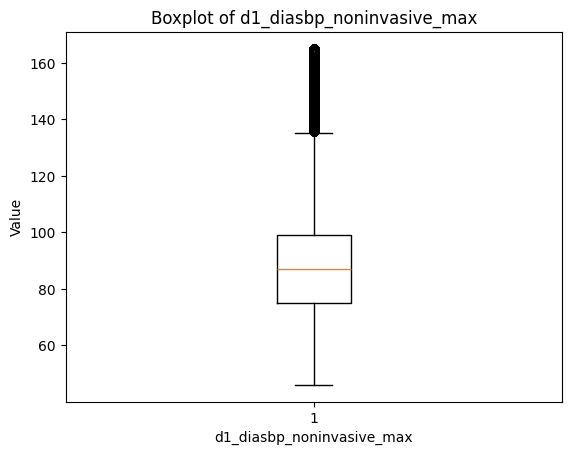

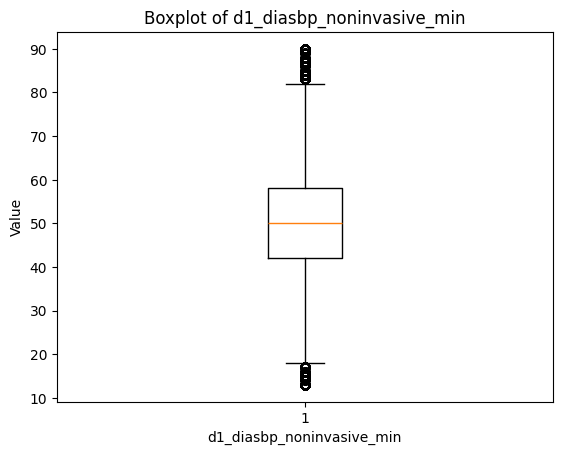

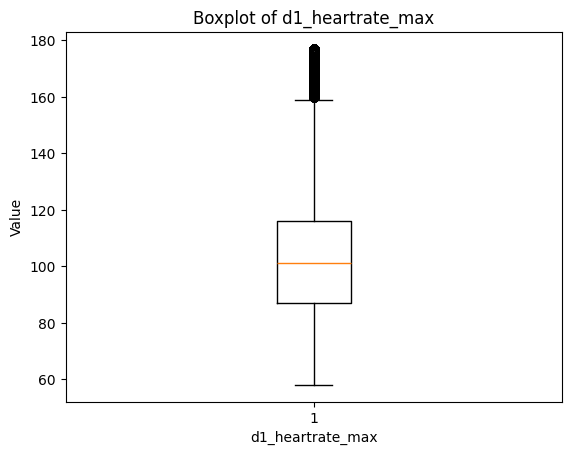

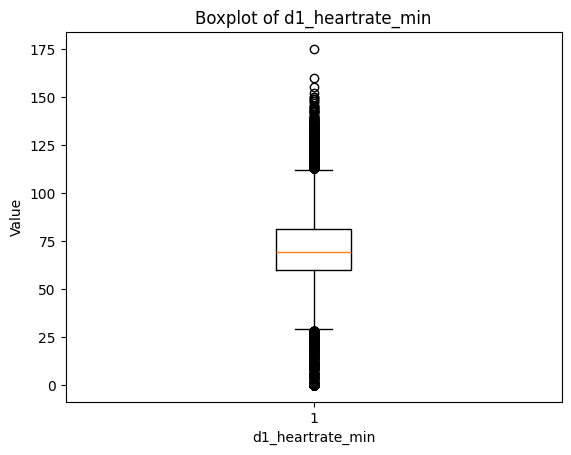

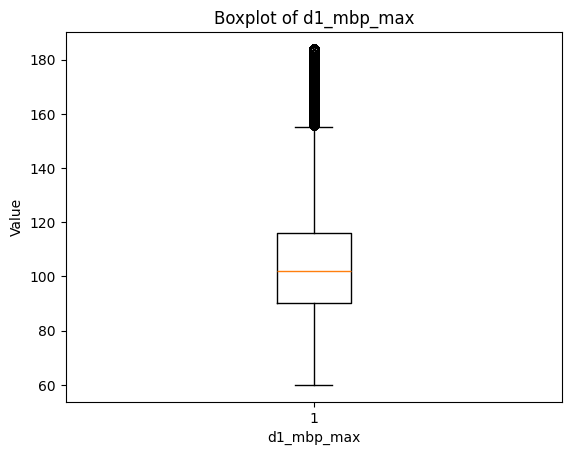

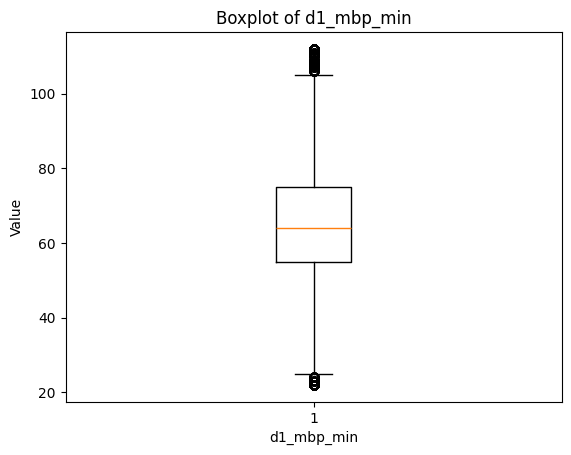

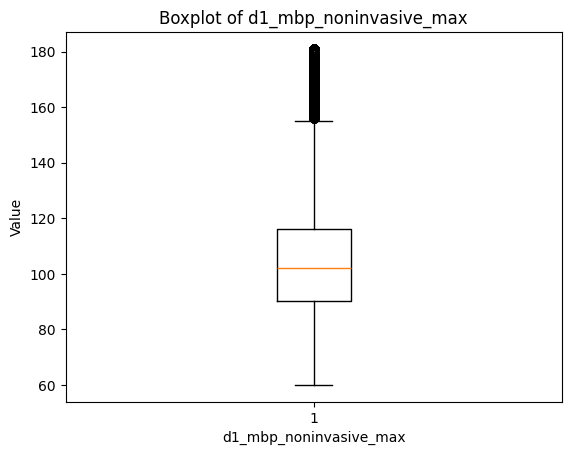

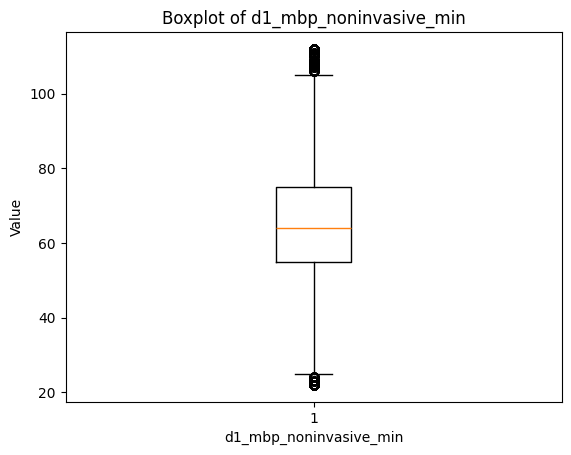

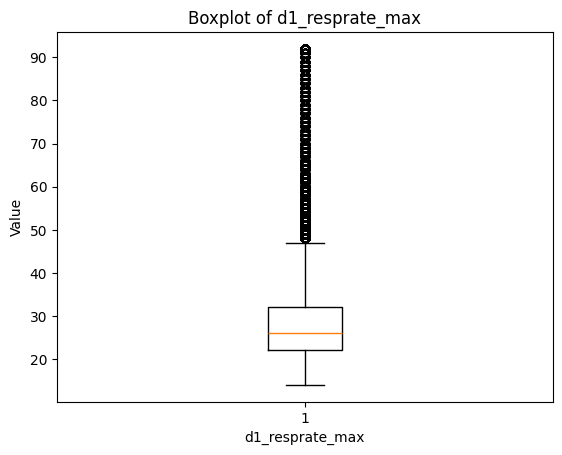

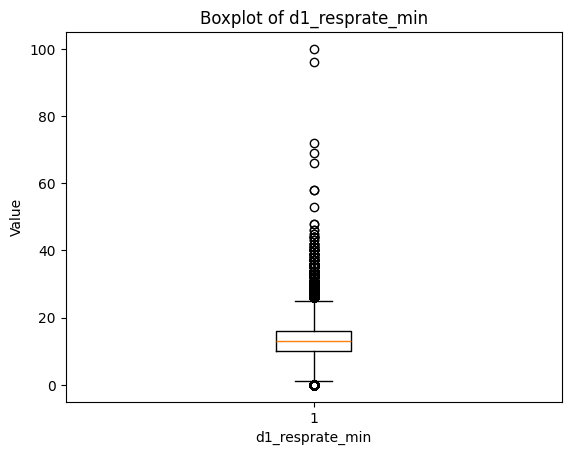

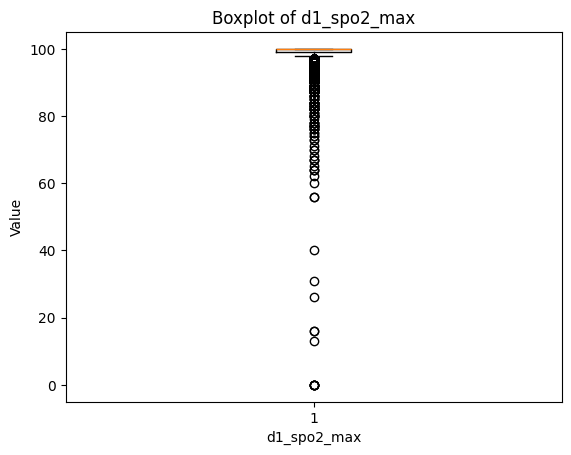

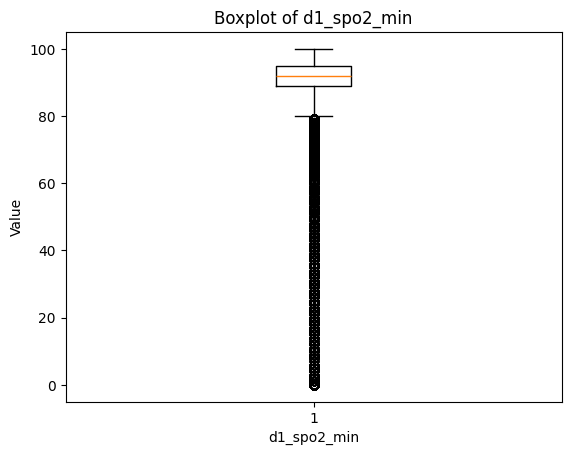

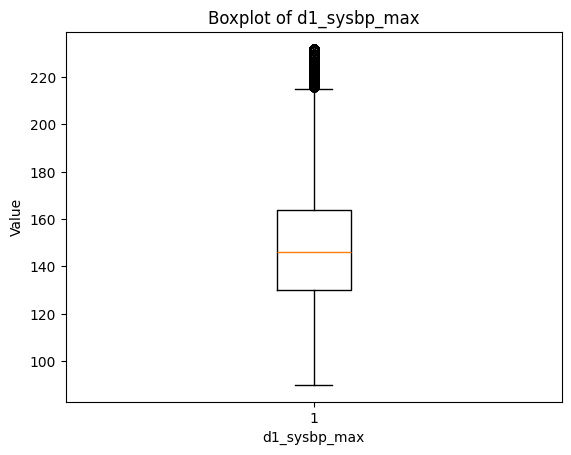

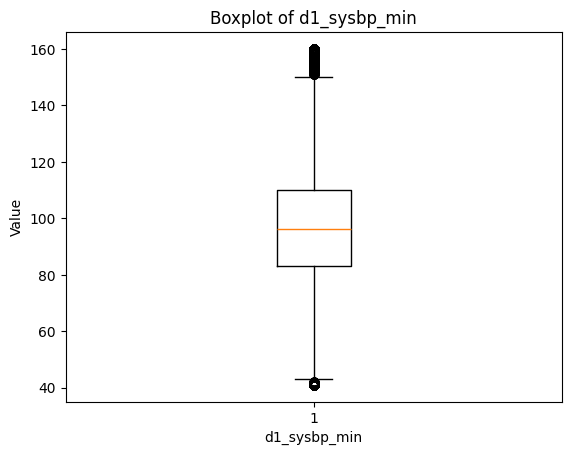

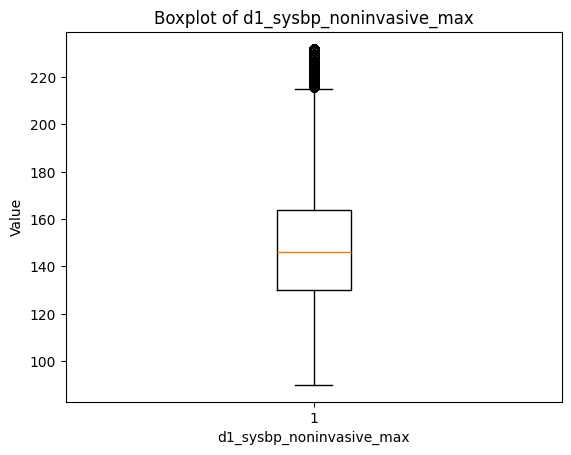

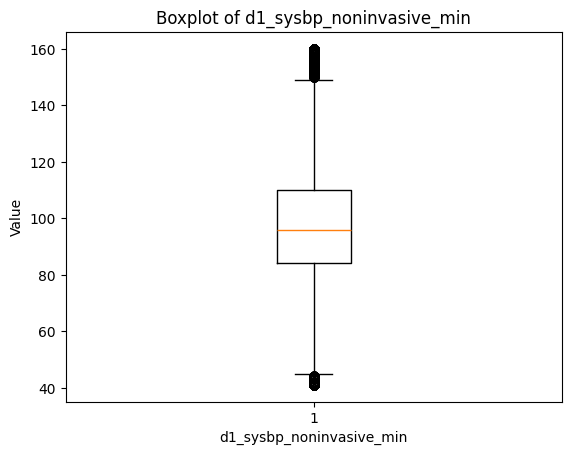

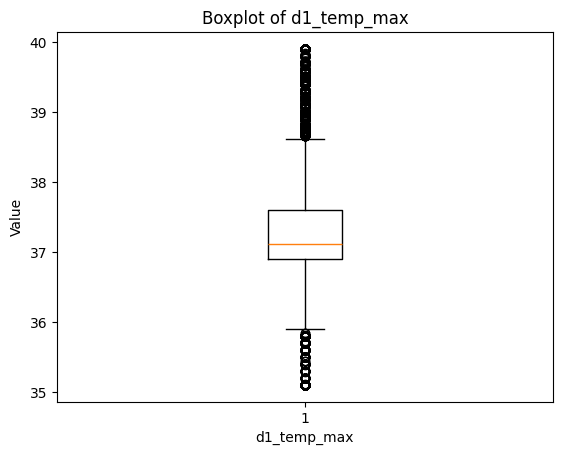

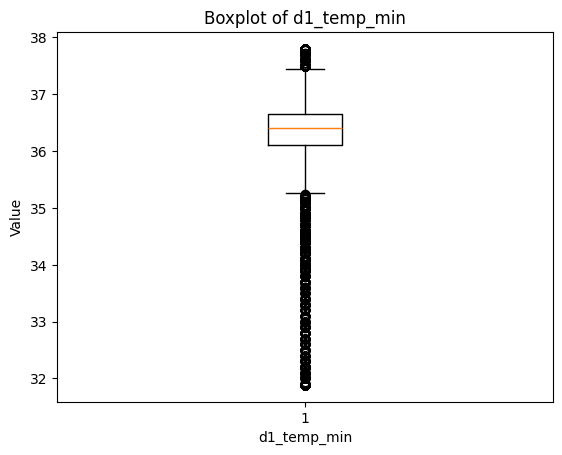

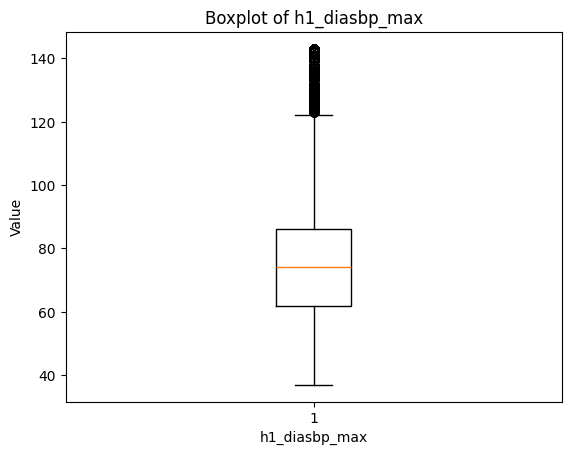

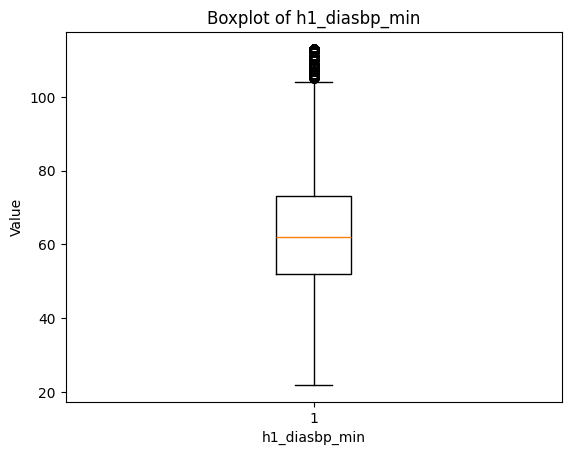

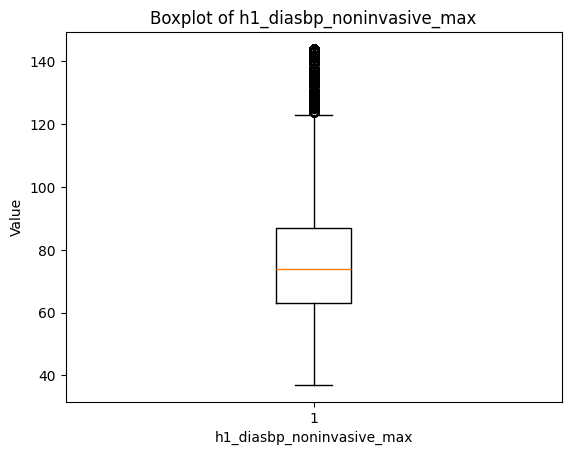

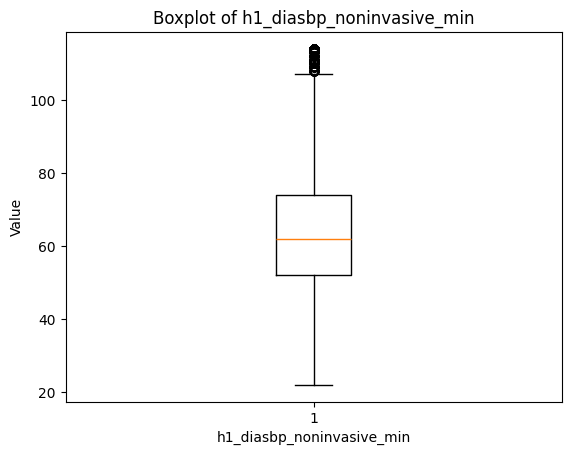

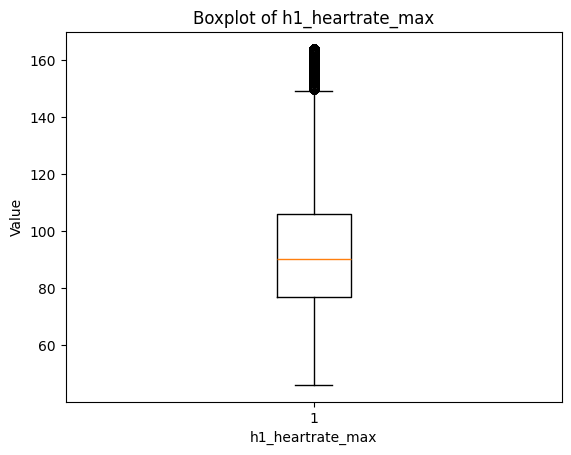

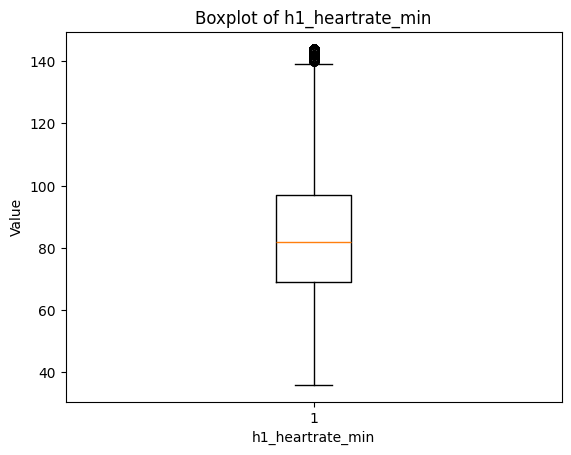

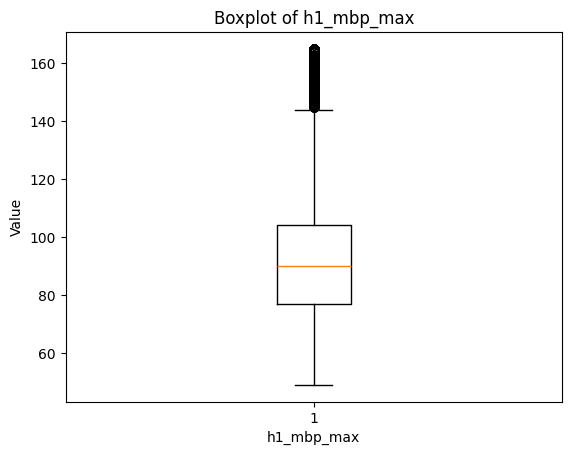

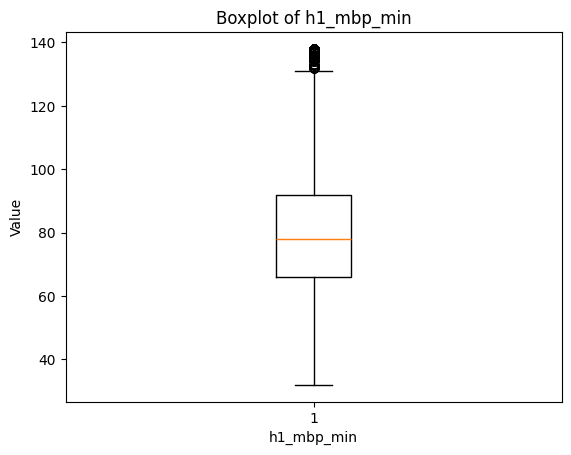

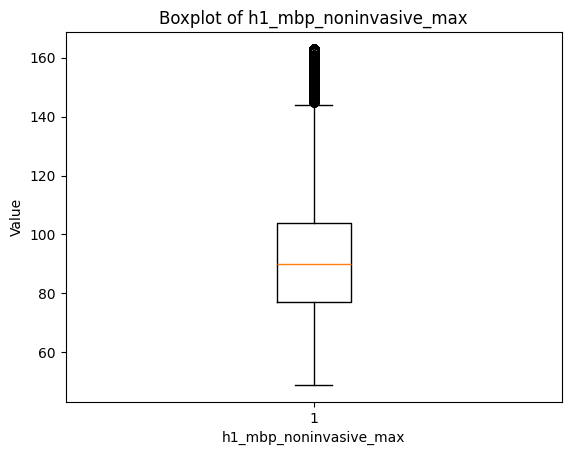

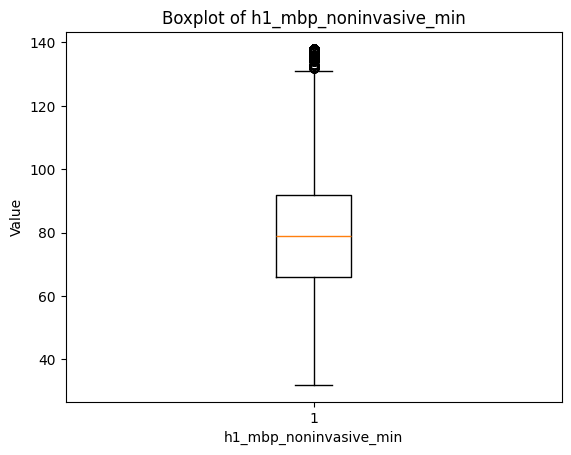

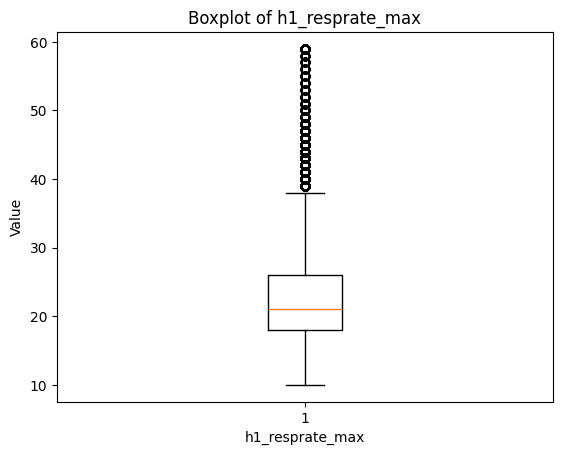

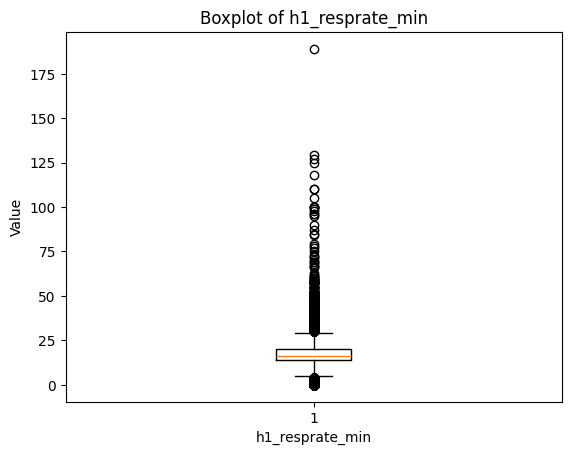

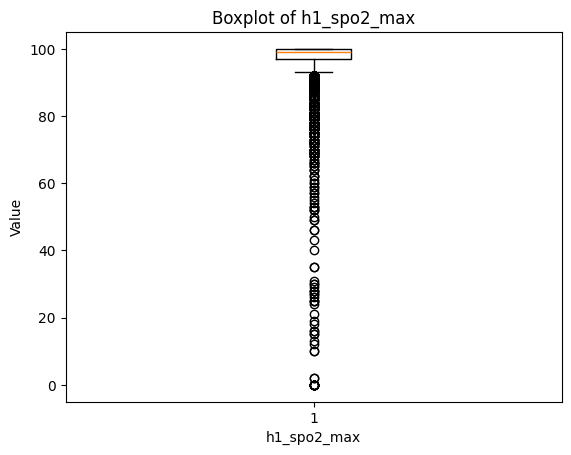

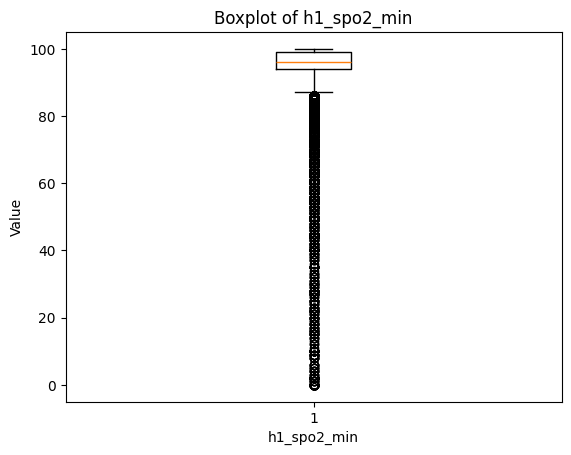

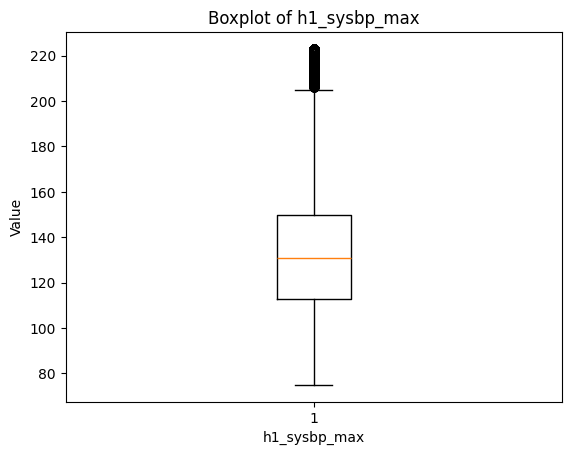

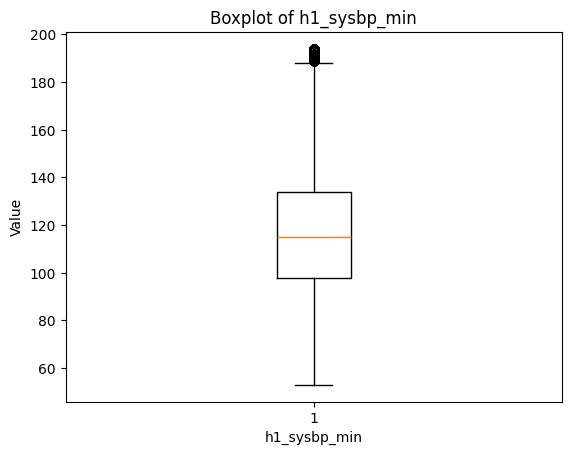

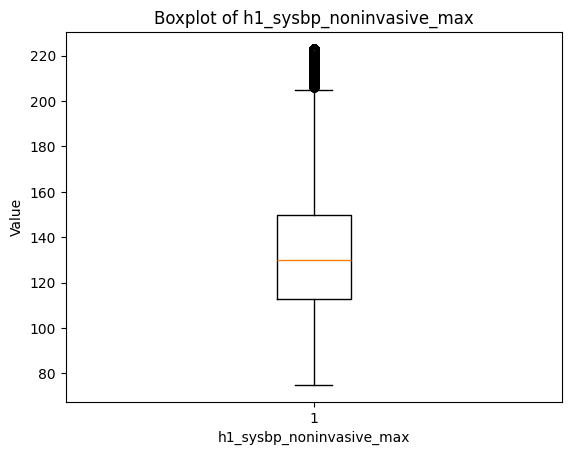

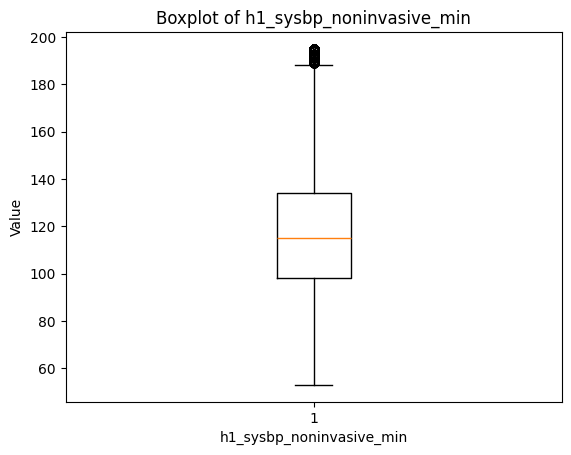

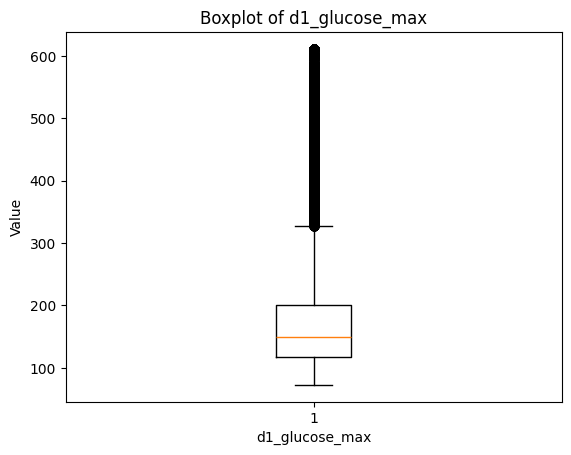

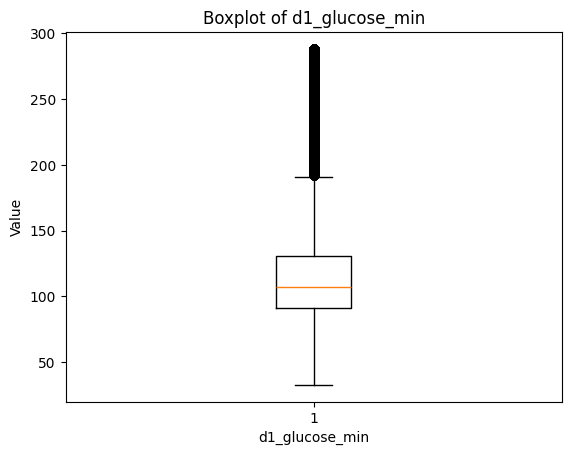

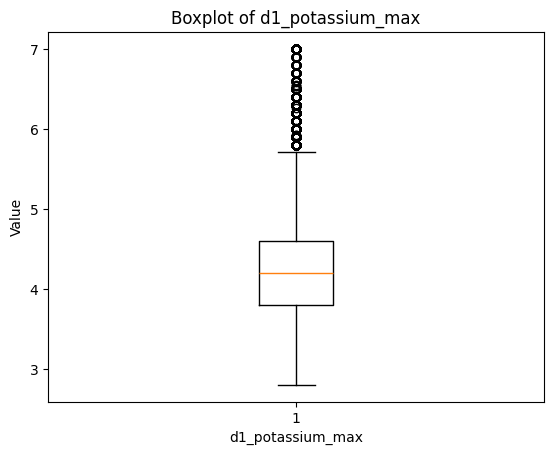

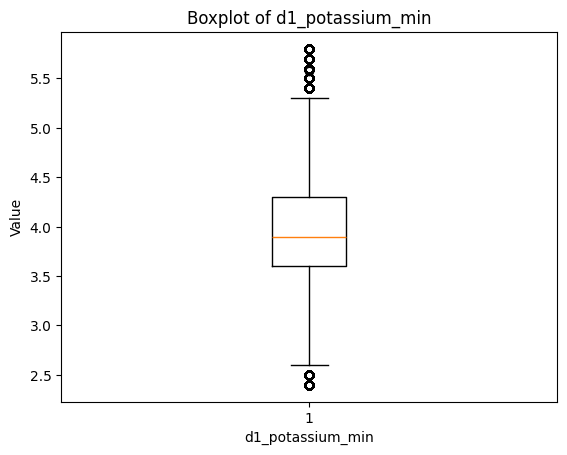

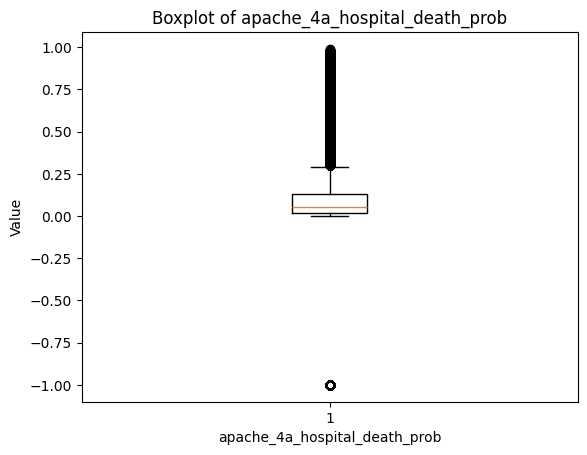

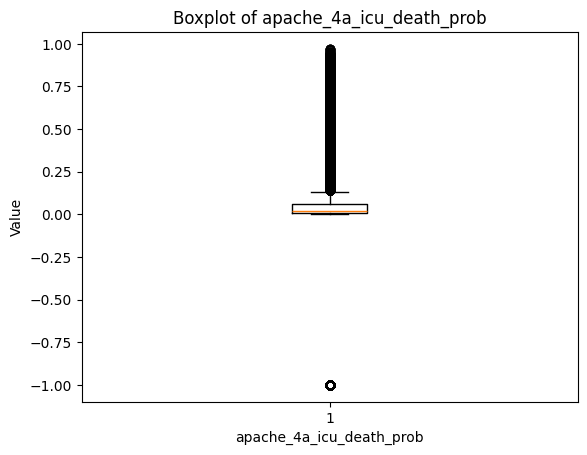

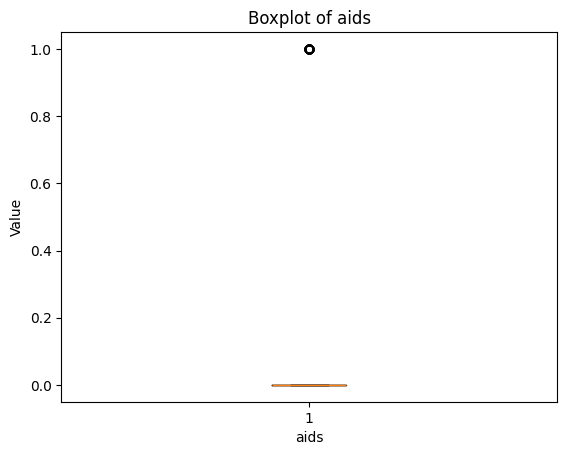

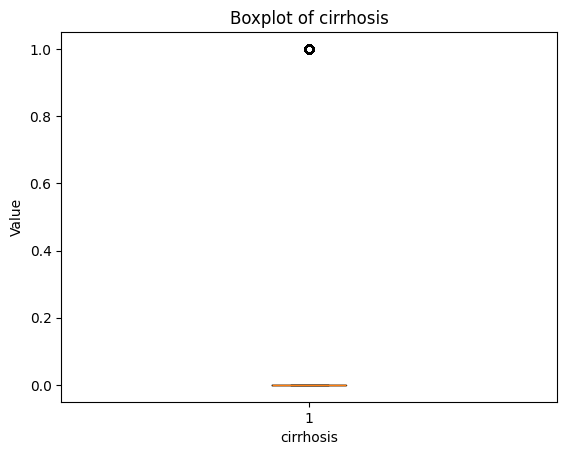

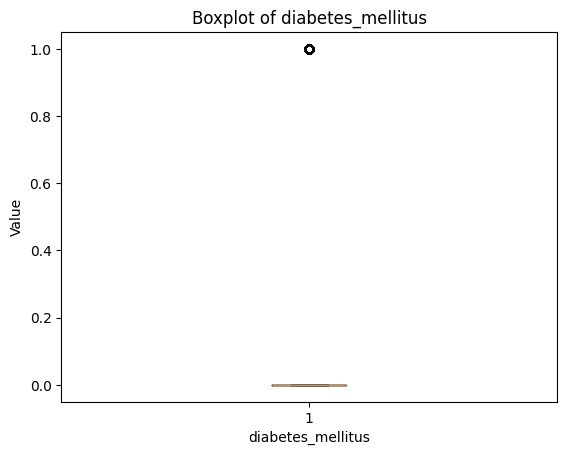

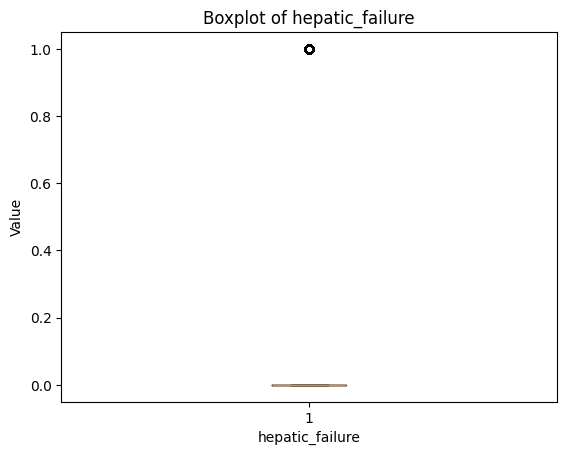

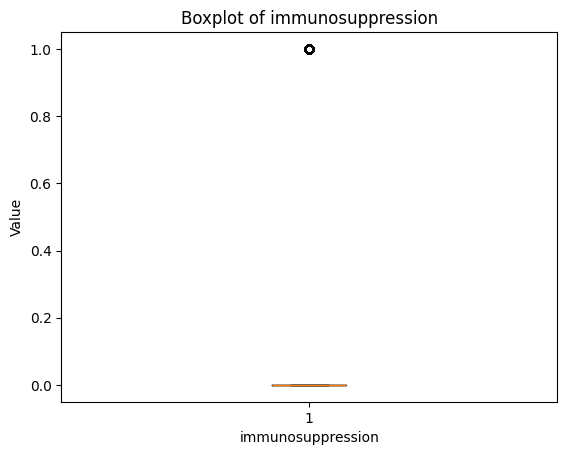

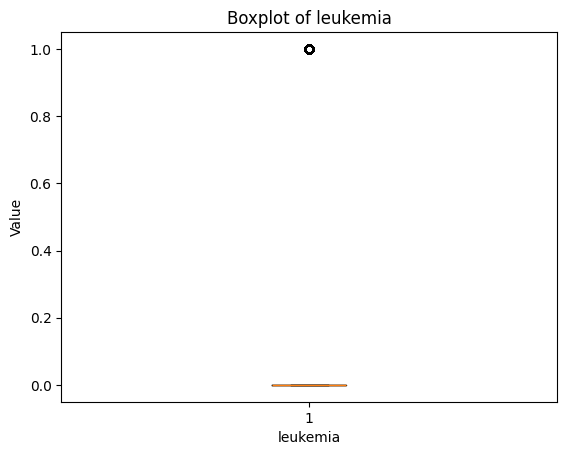

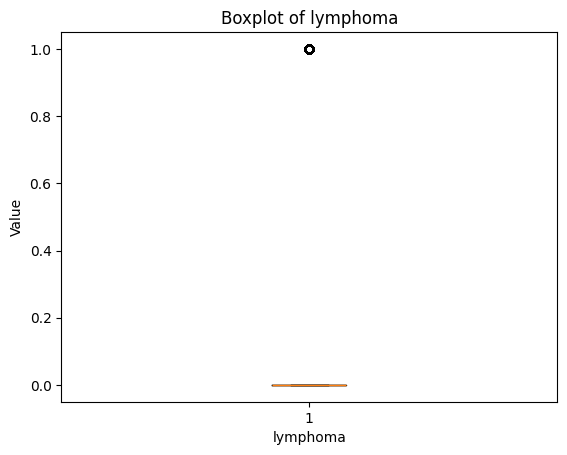

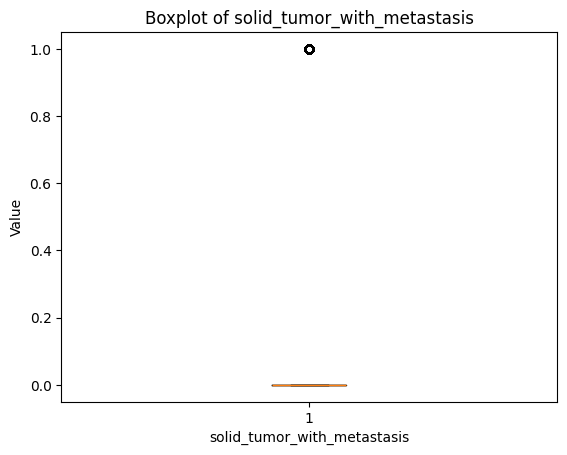

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Prepare Data
target = "hospital_death"
df_work = df.copy()

# Select numeric columns only
numeric_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()

# Remove target column
if target in numeric_cols:
    numeric_cols.remove(target)

# Remove fully empty columns
numeric_cols = [col for col in numeric_cols if df_work[col].notna().sum() > 0]

# Step 2: Outlier Function (IQR)
def count_outliers(series):
    series = series.dropna()
    if len(series) == 0:
        return 0

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return ((series < lower_bound) | (series > upper_bound)).sum()

# Step 3: Build Outlier Table
outlier_data = []

for col in numeric_cols:
    outlier_data.append({
        "column": col,
        "outliers_count": count_outliers(df_work[col])
    })

outlier_df = pd.DataFrame(outlier_data)
outlier_df = outlier_df.sort_values(by="outliers_count", ascending=False)

print("Top 20 columns with most outliers:\n")
print(outlier_df.head(20))

# Step 4: Boxplots (ALL columns)
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df_work[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Value")
    plt.show()

In [ ]:
import pandas as pd

outlier_summary = []

for col in df.select_dtypes(include=['int64', 'float64']).columns:

    # skip target column
    if col == "hospital_death":
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    if outlier_count > 0:
        outlier_summary.append({
            "column": col,
            "outlier_count": outlier_count
        })

outlier_table = pd.DataFrame(outlier_summary)

outlier_table

,column,outlier_count
0,age,170
1,bmi,3289
2,elective_surgery,16851
3,height,463
4,pre_icu_los_days,15815
5,weight,2563
6,apache_3j_diagnosis,4575
7,apache_post_operative,18444
8,arf_apache,2546
9,gcs_eyes_apache,8274


In [ ]:
import pandas as pd

df_clean = df.copy()

# columns from your outlier table
outlier_cols = [
    "age","bmi","elective_surgery","height","pre_icu_los_days","weight",
    "apache_3j_diagnosis","apache_post_operative","arf_apache","gcs_eyes_apache",
    "gcs_motor_apache","gcs_unable_apache","gcs_verbal_apache","heart_rate_apache",
    "intubated_apache","temp_apache","d1_diasbp_max","d1_diasbp_min",
    "d1_diasbp_noninvasive_max","d1_diasbp_noninvasive_min","d1_heartrate_max",
    "d1_heartrate_min","d1_mbp_max","d1_mbp_min","d1_mbp_noninvasive_max",
    "d1_mbp_noninvasive_min","d1_resprate_max","d1_resprate_min","d1_spo2_max",
    "d1_spo2_min","d1_sysbp_max","d1_sysbp_min","d1_sysbp_noninvasive_max",
    "d1_sysbp_noninvasive_min","d1_temp_max","d1_temp_min","h1_diasbp_max",
    "h1_diasbp_min","h1_diasbp_noninvasive_max","h1_diasbp_noninvasive_min",
    "h1_heartrate_max","h1_heartrate_min","h1_mbp_max","h1_mbp_min",
    "h1_mbp_noninvasive_max","h1_mbp_noninvasive_min","h1_resprate_max",
    "h1_resprate_min","h1_spo2_max","h1_spo2_min","h1_sysbp_max",
    "h1_sysbp_min","h1_sysbp_noninvasive_max","h1_sysbp_noninvasive_min",
    "d1_glucose_max","d1_glucose_min","d1_potassium_max","d1_potassium_min",
    "apache_4a_hospital_death_prob","apache_4a_icu_death_prob",
    "aids","cirrhosis","diabetes_mellitus","hepatic_failure",
    "immunosuppression","leukemia","lymphoma","solid_tumor_with_metastasis"
]

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # cap values (winsorization)
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

df_clean

In [ ]:
import pandas as pd

remaining_outliers = []

for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:

    if col == "hospital_death":
        continue

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = df_clean[
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ].shape[0]

    if outlier_count > 0:
        remaining_outliers.append({
            "column": col,
            "outlier_count": outlier_count
        })

remaining_outlier_table = pd.DataFrame(remaining_outliers)

#  SAFE CHECK
if not remaining_outlier_table.empty:
    remaining_outlier_table = remaining_outlier_table.sort_values(
        by="outlier_count",
        ascending=False
    )

remaining_outlier_table

""


In [ ]:
import pandas as pd

remaining_outliers = []

for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:

    if col == "hospital_death":
        continue

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()

    if outlier_count > 0:
        remaining_outliers.append([col, outlier_count])

# Create clean table
remaining_outlier_table = pd.DataFrame(
    remaining_outliers,
    columns=["column", "outlier_count"]
)

# Sort only if not empty
if not remaining_outlier_table.empty:
    remaining_outlier_table = remaining_outlier_table.sort_values(
        by="outlier_count",
        ascending=False
    )

remaining_outlier_table

,column,outlier_count


In [ ]:
df_clean.isnull().sum()

,0
encounter_id,0
patient_id,0
hospital_id,0
age,4228
bmi,3429
elective_surgery,0
ethnicity,1395
gender,25
height,1334
icu_admit_source,112


In [ ]:
import pandas as pd

df_imputed = df_clean.copy()

#  Step 1: Drop fully empty columns (if any still exist)
df_imputed = df_imputed.dropna(axis=1, how='all')

#  Step 2: Median imputation for numeric columns
num_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if df_imputed[col].isnull().sum() > 0:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

#  Step 3: Mode imputation for categorical columns
cat_cols = df_imputed.select_dtypes(include=['object']).columns

for col in cat_cols:
    if df_imputed[col].isnull().sum() > 0:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

In [ ]:
df_imputed.isnull().sum()

,0
encounter_id,0
patient_id,0
hospital_id,0
age,0
bmi,0
elective_surgery,0
ethnicity,0
gender,0
height,0
icu_admit_source,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# correlation with target
corr = df_imputed.corr(numeric_only=True)["hospital_death"].sort_values(ascending=False)

corr

,hospital_death
hospital_death,1.000000
apache_4a_hospital_death_prob,0.365686
apache_4a_icu_death_prob,0.358289
ventilated_apache,0.226405
d1_heartrate_max,0.161652
h1_resprate_max,0.126811
d1_resprate_max,0.123613
h1_resprate_min,0.112591
h1_heartrate_max,0.112012
age,0.108317


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# correlation of all numeric columns
corr_matrix = df_imputed.corr(numeric_only=True)

In [ ]:
target_corr = corr_matrix["hospital_death"].sort_values(ascending=False)

In [ ]:
ordered_cols = target_corr.index

corr_matrix_ordered = corr_matrix.loc[ordered_cols, ordered_cols]

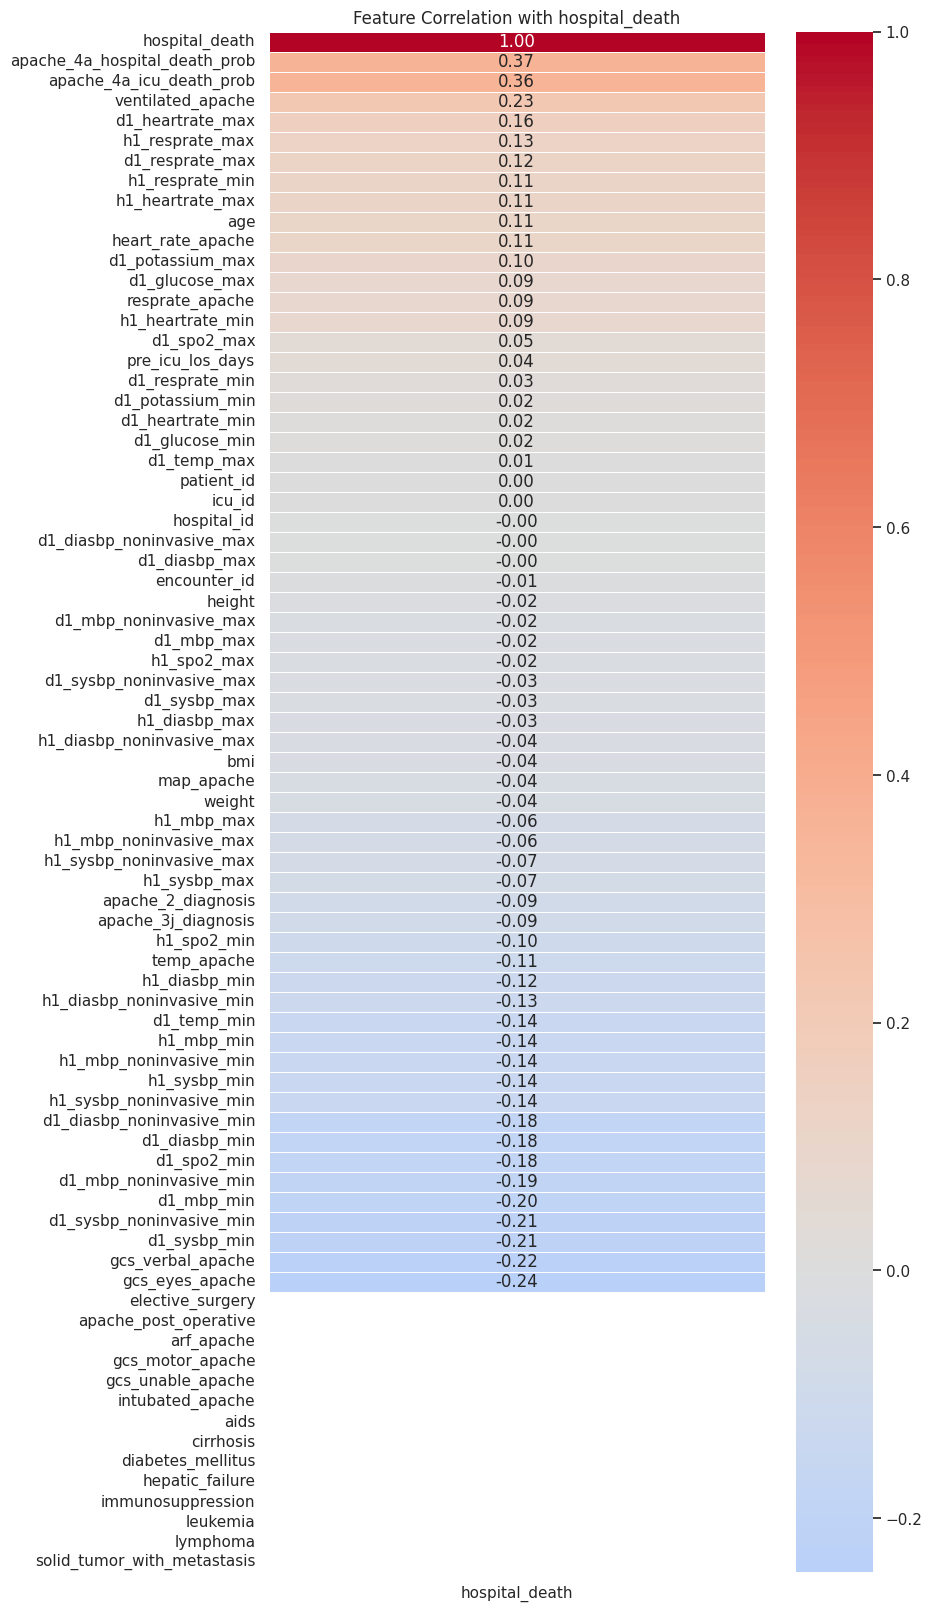

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_target = df_imputed.corr(numeric_only=True)[["hospital_death"]].sort_values(
    by="hospital_death", ascending=False
)

plt.figure(figsize=(8, 20))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation with hospital_death")
plt.show()

In [ ]:
cols_to_drop = [
    'elective_surgery',
    'apache_post_operative',
    'arf_apache',
    'gcs_motor_apache',
    'gcs_unable_apache',
    'intubated_apache',
    'aids',
    'cirrhosis',
    'diabetes_mellitus',
    'hepatic_failure',
    'immunosuppression',
    'leukemia',
    'lymphoma',
    'solid_tumor_with_metastasis'
]

df_imputed.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df_imputed.drop(columns=[
    "encounter_id",
    "patient_id",
    "hospital_id",
    "icu_id"
], inplace=True)

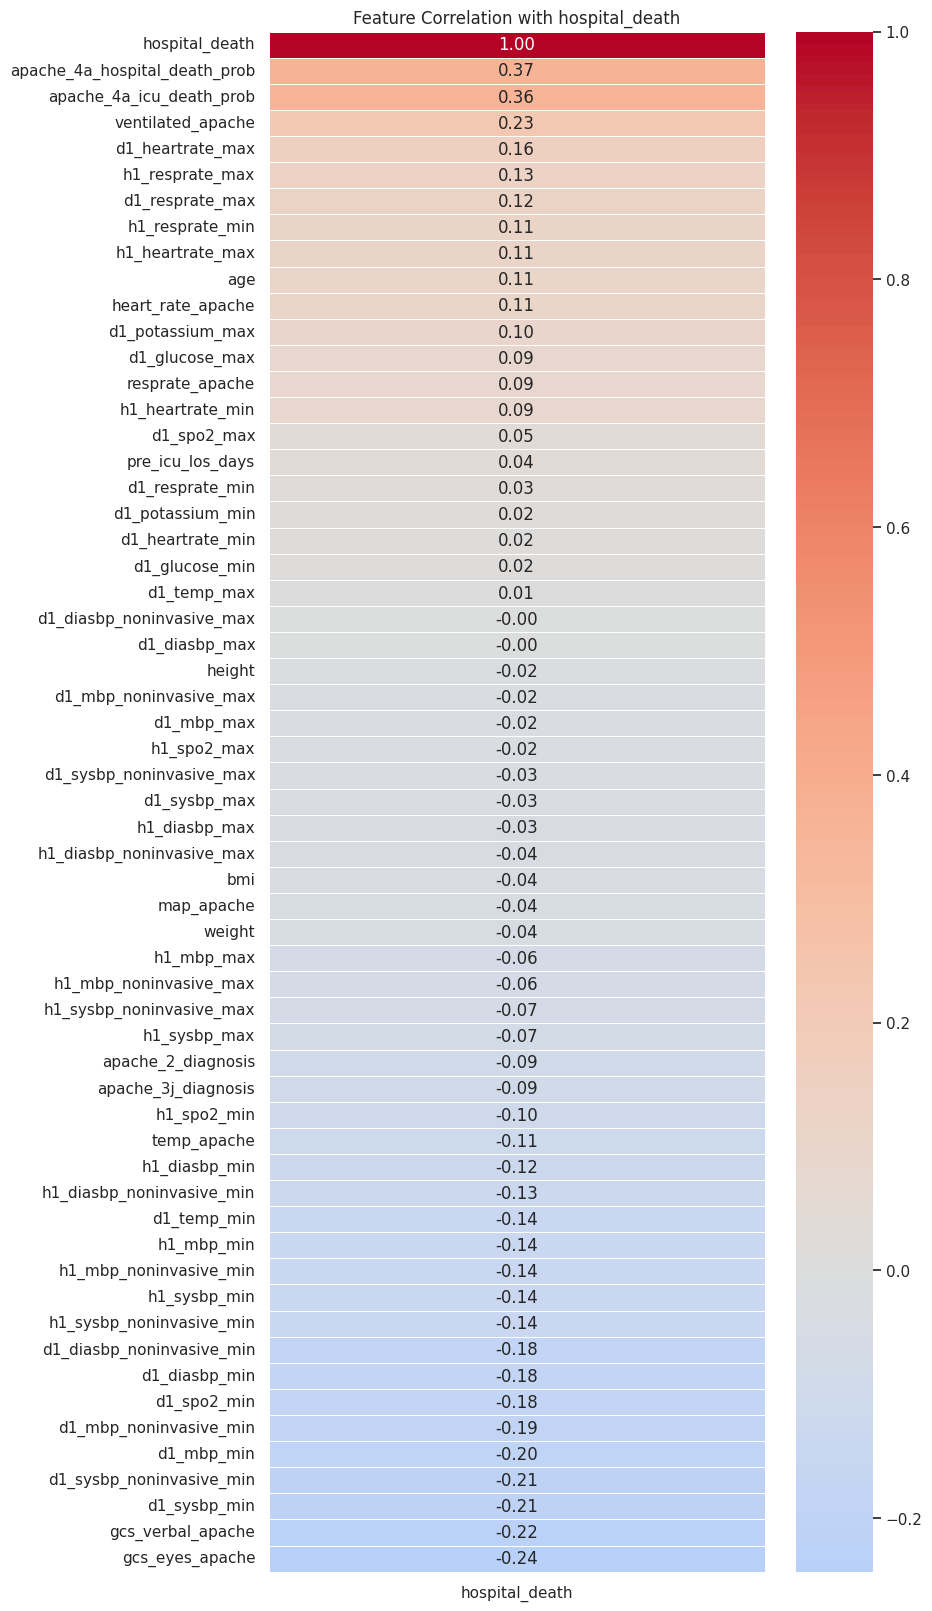

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_target = df_imputed.corr(numeric_only=True)[["hospital_death"]].sort_values(
    by="hospital_death", ascending=False
)

plt.figure(figsize=(8, 20))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation with hospital_death")
plt.show()

In [ ]:
cols = [
    'd1_diasbp_noninvasive_max', 'd1_diasbp_max', 'd1_temp_max',
    'd1_potassium_min', 'd1_heartrate_min', 'd1_glucose_min',
    'height', 'd1_temp_min', 'pre_icu_los_days', 'd1_resprate_min',
    'd1_spo2_max', 'd1_diasbp_noninvasive_min', 'd1_mbp_noninvasive_max',
    'd1_mbp_noninvasive_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min',
    'h1_diasbp_noninvasive_max', 'h1_diasbp_noninvasive_min', 'h1_mbp_noninvasive_max',
    'h1_mbp_noninvasive_min', 'h1_sysbp_noninvasive_max', 'h1_sysbp_noninvasive_min',
    'weight', 'bmi'
]

# compute correlation with target
corr_with_target = df_imputed[cols + ['hospital_death']].corr()['hospital_death'].sort_values(ascending=False)

print(corr_with_target)

hospital_death               1.000000
d1_spo2_max                  0.045713
pre_icu_los_days             0.038562
d1_resprate_min              0.025987
d1_potassium_min             0.019847
d1_heartrate_min             0.018814
d1_glucose_min               0.017376
d1_temp_max                  0.008097
d1_diasbp_noninvasive_max   -0.001398
d1_diasbp_max               -0.002075
height                      -0.019177
d1_mbp_noninvasive_max      -0.020290
d1_sysbp_noninvasive_max    -0.028704
h1_diasbp_noninvasive_max   -0.037019
bmi                         -0.037436
weight                      -0.041969
h1_mbp_noninvasive_max      -0.063052
h1_sysbp_noninvasive_max    -0.066619
h1_diasbp_noninvasive_min   -0.128610
d1_temp_min                 -0.137247
h1_mbp_noninvasive_min      -0.143236
h1_sysbp_noninvasive_min    -0.144650
d1_diasbp_noninvasive_min   -0.178337
d1_mbp_noninvasive_min      -0.194445
d1_sysbp_noninvasive_min    -0.209232
Name: hospital_death, dtype: float64


In [ ]:
cols_to_drop = [
    'd1_spo2_max',
    'pre_icu_los_days',
    'd1_resprate_min',
    'd1_potassium_min',
    'd1_heartrate_min',
    'd1_glucose_min',
    'd1_temp_max',
    'd1_diasbp_noninvasive_max',
    'd1_diasbp_max',
    'height',
    'd1_mbp_noninvasive_max',
    'd1_sysbp_noninvasive_max',
    'h1_diasbp_noninvasive_max',
    'bmi',
    'weight',
    'h1_mbp_noninvasive_max',
    'h1_sysbp_noninvasive_max'
]

df_imputed.drop(columns=cols_to_drop, inplace=True)

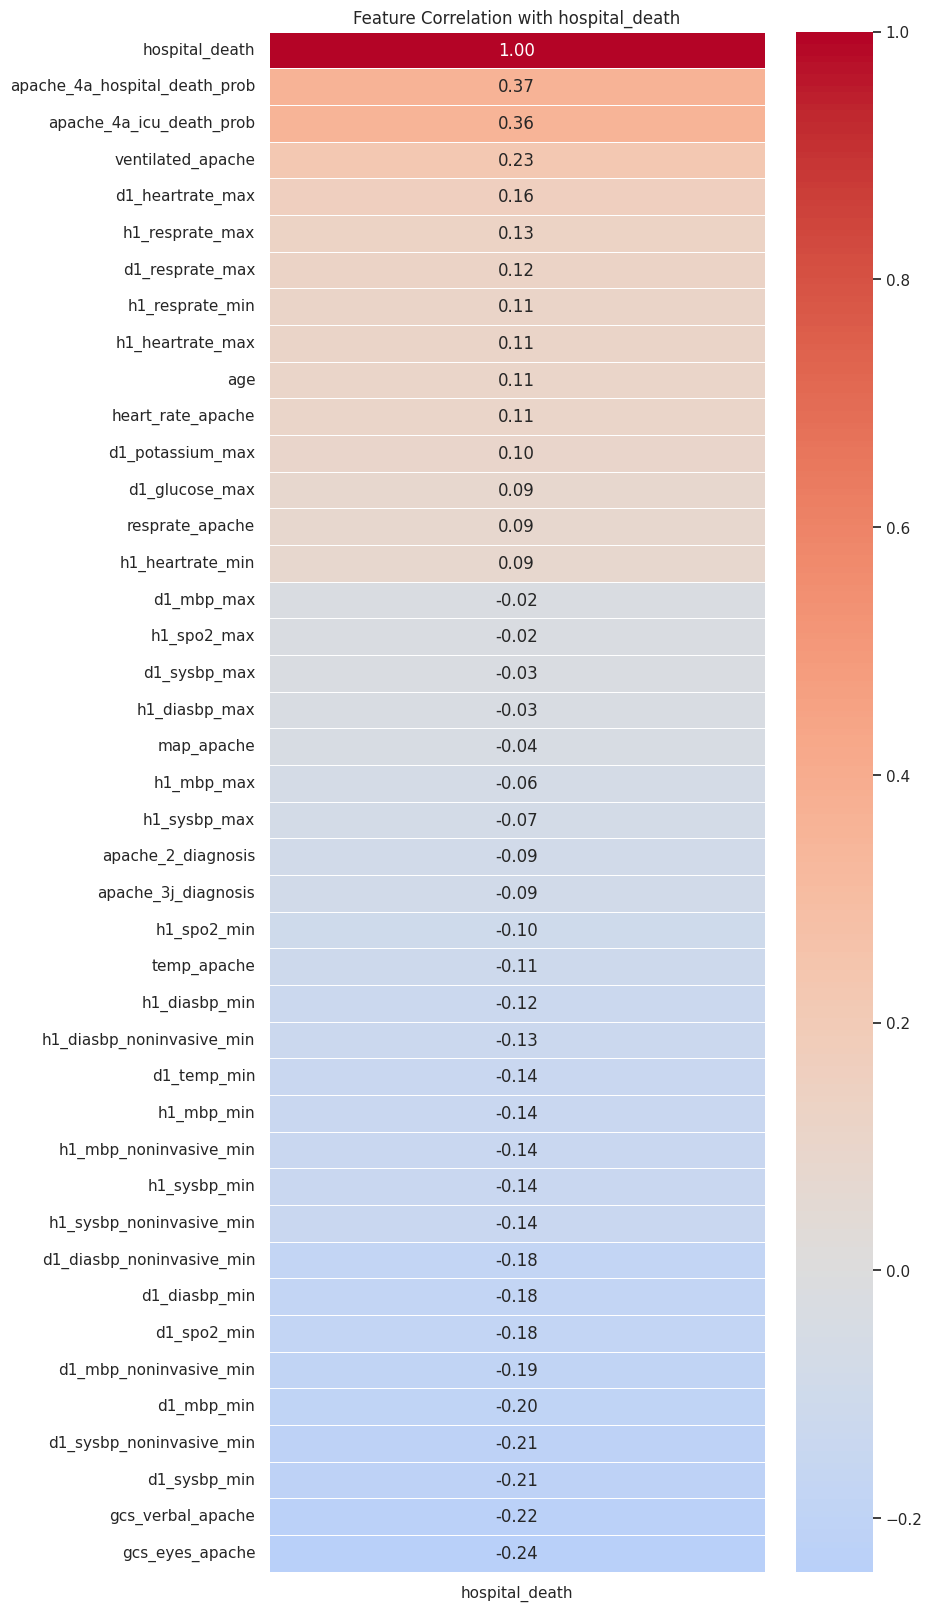

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_target = df_imputed.corr(numeric_only=True)[["hospital_death"]].sort_values(
    by="hospital_death", ascending=False
)

plt.figure(figsize=(8, 20))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation with hospital_death")
plt.show()

In [ ]:
# keep only numeric columns
df_numeric = df_imputed.select_dtypes(include=['int64', 'float64'])

# compute correlation with target
corr = df_numeric.corr()['hospital_death']

# select weak features
cols_to_drop = corr[abs(corr) < 0.05].index.tolist()

# remove target itself if present
if 'hospital_death' in cols_to_drop:
    cols_to_drop.remove('hospital_death')

# drop from original dataframe (not only numeric copy)
df_imputed.drop(columns=cols_to_drop, inplace=True)

print("Dropped columns:", cols_to_drop)

Dropped columns: ['map_apache', 'd1_mbp_max', 'd1_sysbp_max', 'h1_diasbp_max', 'h1_spo2_max']


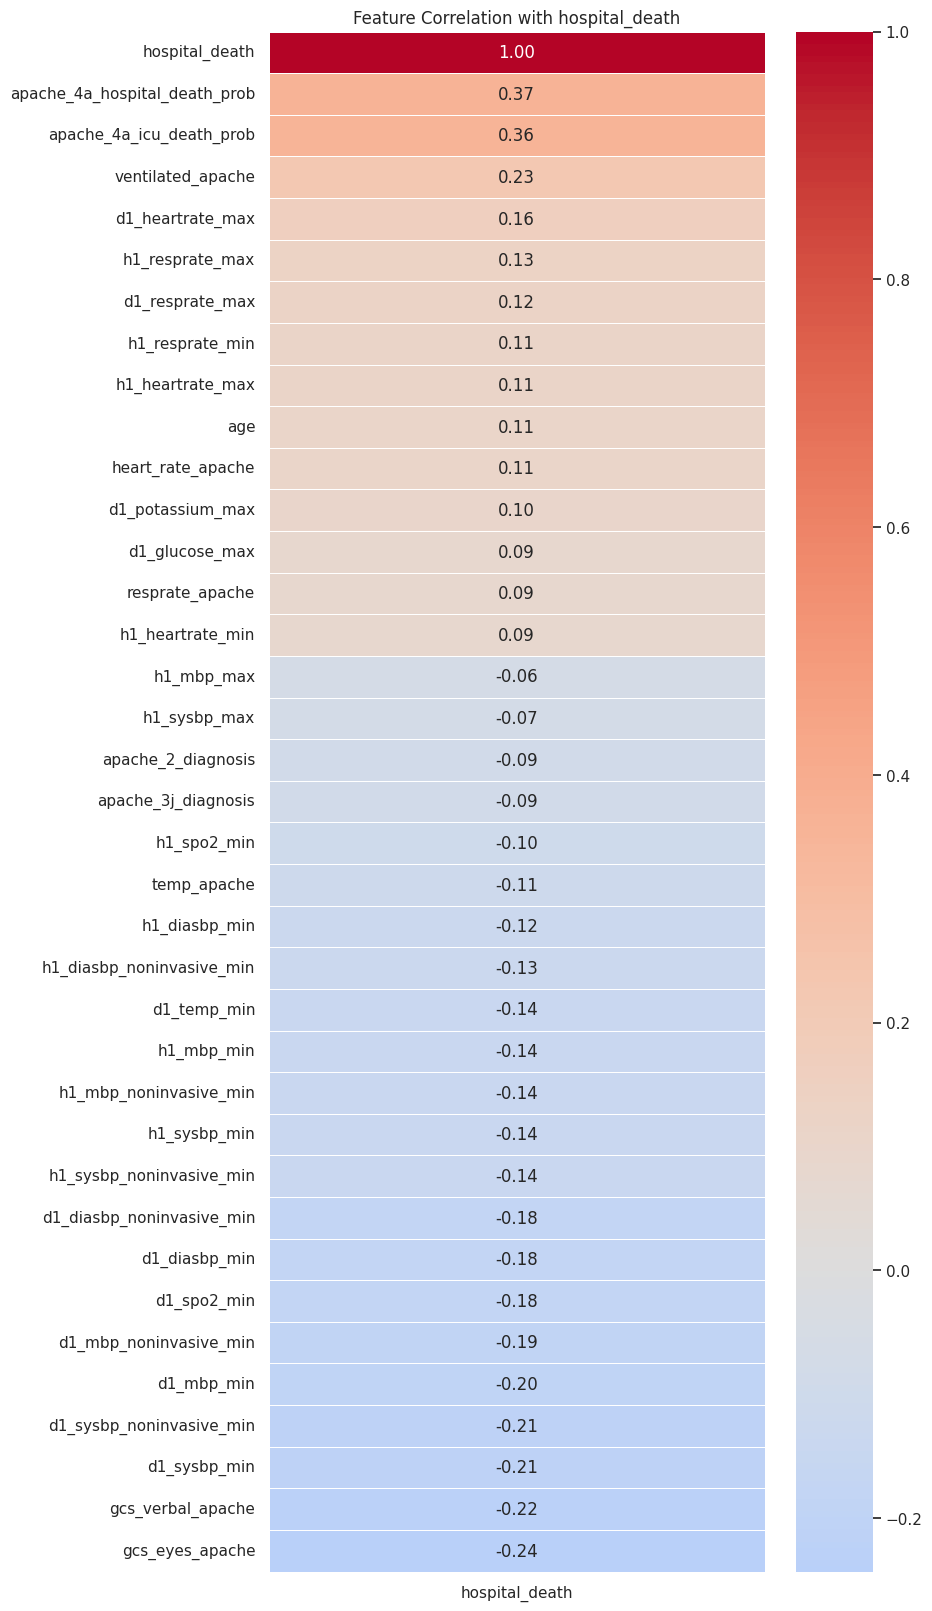

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_target = df_imputed.corr(numeric_only=True)[["hospital_death"]].sort_values(
    by="hospital_death", ascending=False
)

plt.figure(figsize=(8, 20))

sns.heatmap(
    corr_target,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation with hospital_death")
plt.show()

In [ ]:
df_imputed.head()

,age,ethnicity,gender,icu_admit_source,icu_stay_type,icu_type,apache_2_diagnosis,apache_3j_diagnosis,gcs_eyes_apache,gcs_verbal_apache,...,h1_sysbp_max,h1_sysbp_min,h1_sysbp_noninvasive_min,d1_glucose_max,d1_potassium_max,apache_4a_hospital_death_prob,apache_4a_icu_death_prob,apache_3j_bodysystem,apache_2_bodysystem,hospital_death
0,68.0,Caucasian,M,Floor,admit,CTICU,113.0,502.01,3.0,4.0,...,131.0,115.0,115.0,168.0,4.0,0.100,0.050,Sepsis,Cardiovascular,0
1,77.0,Caucasian,F,Floor,admit,MedSurg ICU,108.0,203.01,1.5,2.5,...,95.0,71.0,71.0,145.0,4.2,0.295,0.135,Respiratory,Respiratory,0
2,25.0,Caucasian,F,Accident Emergency,admit,MedSurg ICU,122.0,703.03,3.0,5.0,...,148.0,124.0,124.0,150.0,4.2,0.000,0.000,Metabolic,Metabolic,0
3,81.0,Caucasian,F,Operating Room Recovery,admit,CTICU,203.0,1206.03,4.0,5.0,...,136.0,106.0,115.0,185.0,5.0,0.040,0.030,Cardiovascular,Cardiovascular,0
4,19.0,Caucasian,M,Accident Emergency,admit,MedSurg ICU,119.0,601.01,4.0,5.0,...,130.0,120.0,120.0,150.0,4.2,0.050,0.020,Trauma,Trauma,0


In [ ]:
df_imputed.isnull().sum()

,0
age,0
ethnicity,0
gender,0
icu_admit_source,0
icu_stay_type,0
icu_type,0
apache_2_diagnosis,0
apache_3j_diagnosis,0
gcs_eyes_apache,0
gcs_verbal_apache,0


In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            91713 non-null  float64
 1   ethnicity                      91713 non-null  object 
 2   gender                         91713 non-null  object 
 3   icu_admit_source               91713 non-null  object 
 4   icu_stay_type                  91713 non-null  object 
 5   icu_type                       91713 non-null  object 
 6   apache_2_diagnosis             91713 non-null  float64
 7   apache_3j_diagnosis            91713 non-null  float64
 8   gcs_eyes_apache                91713 non-null  float64
 9   gcs_verbal_apache              91713 non-null  float64
 10  heart_rate_apache              91713 non-null  float64
 11  resprate_apache                91713 non-null  float64
 12  temp_apache                    91713 non-null 

In [ ]:
cols_to_int = [
    'age',
    'apache_2_diagnosis',
    'apache_3j_diagnosis',
    'heart_rate_apache',
    'resprate_apache',
    'temp_apache',
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob'
]

# add all gcs_* columns
cols_to_int += [col for col in df_imputed.columns if col.startswith('gcs_')]

# add all d1_* and h1_* columns
cols_to_int += [col for col in df_imputed.columns if col.startswith('d1_')]
cols_to_int += [col for col in df_imputed.columns if col.startswith('h1_')]

# convert to int (safe handling of NaN/float)
df_imputed[cols_to_int] = df_imputed[cols_to_int].astype('int64')

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 44 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            91713 non-null  int64  
 1   ethnicity                      91713 non-null  object 
 2   gender                         91713 non-null  object 
 3   icu_admit_source               91713 non-null  object 
 4   icu_stay_type                  91713 non-null  object 
 5   icu_type                       91713 non-null  object 
 6   apache_2_diagnosis             91713 non-null  int64  
 7   apache_3j_diagnosis            91713 non-null  int64  
 8   gcs_eyes_apache                91713 non-null  int64  
 9   gcs_verbal_apache              91713 non-null  int64  
 10  heart_rate_apache              91713 non-null  int64  
 11  resprate_apache                91713 non-null  int64  
 12  temp_apache                    91713 non-null 


##  Data Preprocessing & Feature Selection Summary

In this stage of the project, I performed data cleaning, transformation, and feature selection on the ICU patient dataset (`df_imputed`) to prepare it for machine learning modeling.

### 1. Handling Correlation with Target Variable

* Calculated the correlation of all numerical features with the target variable **`hospital_death`**
* Identified features with very weak correlation (|correlation| < 0.05)
* Dropped these low-impact features to reduce noise and improve model performance

### 2. Feature Reduction

* Removed irrelevant or weakly related clinical variables such as:

  * Vital sign minimum/maximum values with very low correlation
  * Some demographic and ICU stay-related variables with minimal predictive value
* This helped in reducing dimensionality and improving model efficiency

### 3. Data Type Optimization

* Converted important clinical measurement columns into integer format where appropriate, including:

  * Age
  * APACHE diagnosis scores
  * GCS scores (`gcs_*`)
  * Vital signs (`d1_*`, `h1_*`, etc.)
* Kept probability-based features (`apache_4a_*`) as float since they represent continuous values between 0 and 1

### 4. Categorical Data Handling (Preparation Stage)

* Identified categorical variables such as:

  * ethnicity, gender, ICU type, ICU stay type, body systems
* These features are planned for encoding (e.g., one-hot encoding) before model training

### 5. Final Dataset Preparation

* Ensured dataset is mostly numeric and clean
* Removed inconsistencies caused by object-type columns for correlation analysis
* Prepared dataset for machine learning model training by improving feature quality and consistency



## Outcome

The dataset is now:

* Cleaner and more structured
* Reduced in dimensionality
* Optimized for predictive modeling of ICU mortality (`hospital_death`)




In [ ]:
df.to_csv("Before_Onehot_encoding.csv", index=False)

In [ ]:
from google.colab import files

df.to_csv("Before_Onehot_encoding.csv", index=False)
files.download("Before_Onehot_encoding.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Count of each class
print(df_imputed['hospital_death'].value_counts())

# Percentage distribution
print(df_imputed['hospital_death'].value_counts(normalize=True) * 100)

hospital_death
0    83798
1     7915
Name: count, dtype: int64
hospital_death
0    91.369817
1     8.630183
Name: proportion, dtype: float64


In [ ]:
df_imputed['hospital_death'].value_counts()

,count
hospital_death,
0,83798
1,7915


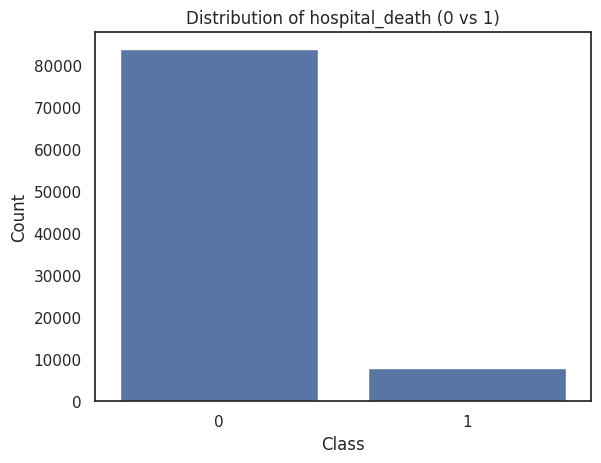

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df_imputed['hospital_death'])
plt.title("Distribution of hospital_death (0 vs 1)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.utils import resample
import pandas as pd

# Separate majority and minority classes
df_majority = df_imputed[df_imputed['hospital_death'] == 0]
df_minority = df_imputed[df_imputed['hospital_death'] == 1]

# Oversample minority class
df_minority_oversampled = resample(
    df_minority,
    replace=True,  # sampling with replacement
    n_samples=len(df_majority),  # match majority class
    random_state=42
)

# Combine both
df_imputed = pd.concat([df_majority, df_minority_oversampled])

# Shuffle dataset
df_imputed = df_imputed.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df_imputed['hospital_death'].value_counts()

,count
hospital_death,
0,83798
1,83798


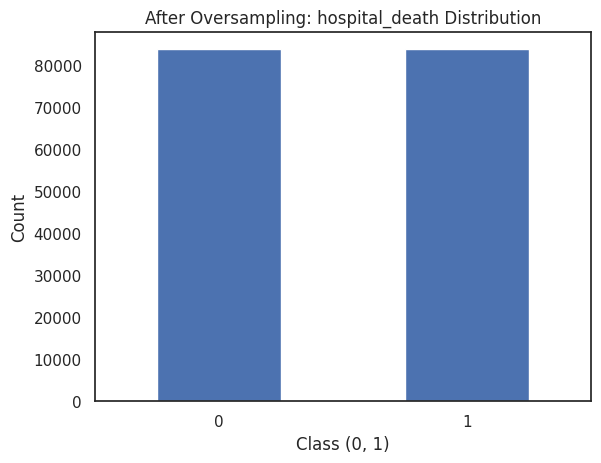

In [ ]:
import matplotlib.pyplot as plt

df_imputed['hospital_death'].value_counts().sort_index().plot(kind='bar')

plt.title("After Oversampling: hospital_death Distribution")
plt.xlabel("Class (0, 1)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from google.colab import files

df_imputed.to_csv("df_imputed_oversampled.csv", index=False)
files.download("df_imputed_oversampled.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167596 entries, 0 to 167595
Data columns (total 44 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            167596 non-null  int64  
 1   ethnicity                      167596 non-null  object 
 2   gender                         167596 non-null  object 
 3   icu_admit_source               167596 non-null  object 
 4   icu_stay_type                  167596 non-null  object 
 5   icu_type                       167596 non-null  object 
 6   apache_2_diagnosis             167596 non-null  int64  
 7   apache_3j_diagnosis            167596 non-null  int64  
 8   gcs_eyes_apache                167596 non-null  int64  
 9   gcs_verbal_apache              167596 non-null  int64  
 10  heart_rate_apache              167596 non-null  int64  
 11  resprate_apache                167596 non-null  int64  
 12  temp_apache                   

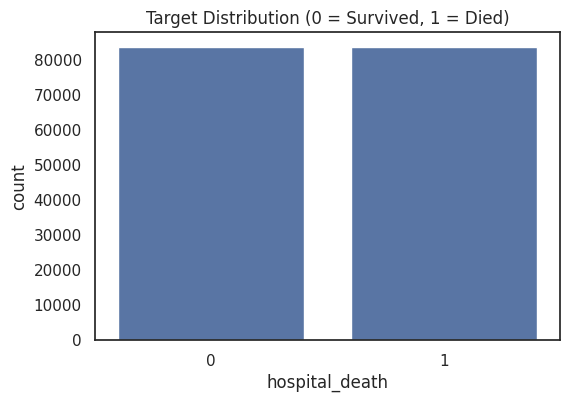

,proportion
hospital_death,
0,50.0
1,50.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='hospital_death', data=df_imputed)
plt.title("Target Distribution (0 = Survived, 1 = Died)")
plt.show()

df_imputed['hospital_death'].value_counts(normalize=True) * 100

In [ ]:
df_imputed.groupby('icu_type')['hospital_death'].mean().sort_values()

,hospital_death
icu_type,
CSICU,0.374516
CTICU,0.403709
CCUCTICU,0.463889
SICU,0.471021
Neuro ICU,0.484922
MedSurg ICU,0.503699
Cardiac ICU,0.556177
MICU,0.591313


# **Exploratory Data Analysis (EDA)**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,4)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

COLOR_MAP = "viridis"

/tmp/ipykernel_6048/977658397.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


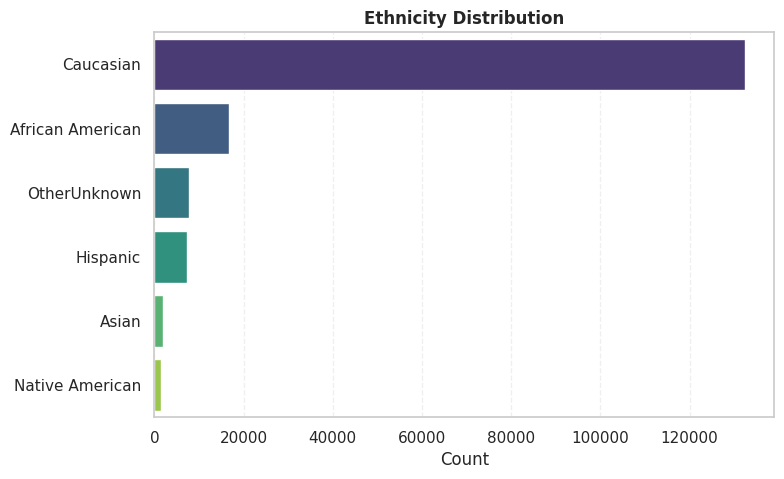

In [ ]:
data = df_imputed['ethnicity'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("Ethnicity Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_6048/3560737995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


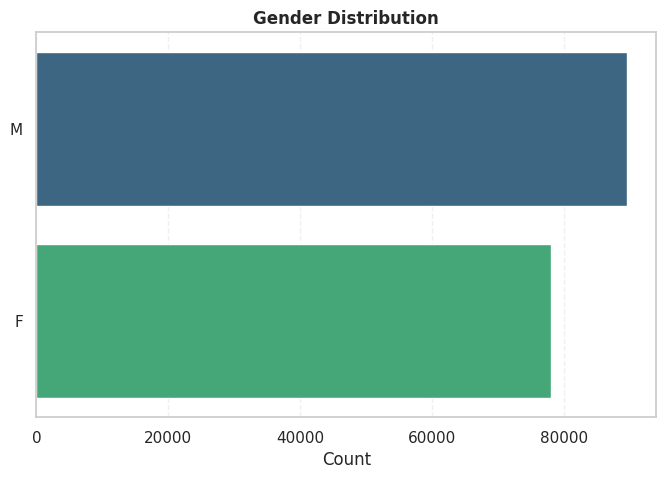

In [ ]:
data = df_imputed['gender'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("Gender Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

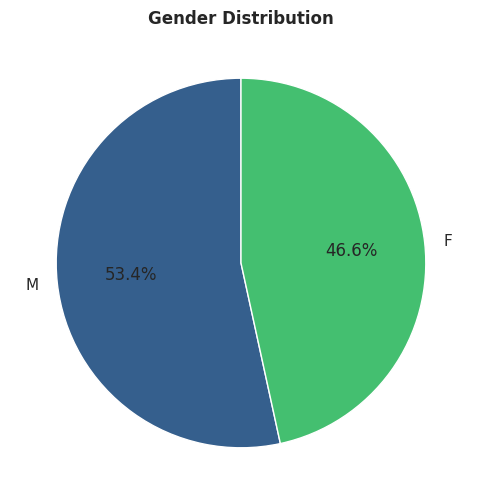

In [ ]:
import matplotlib.pyplot as plt

data = df_imputed['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.viridis([0.3, 0.7])  # consistent theme colors
)

plt.title("Gender Distribution", fontweight='bold')
plt.show()

/tmp/ipykernel_6048/3688991027.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


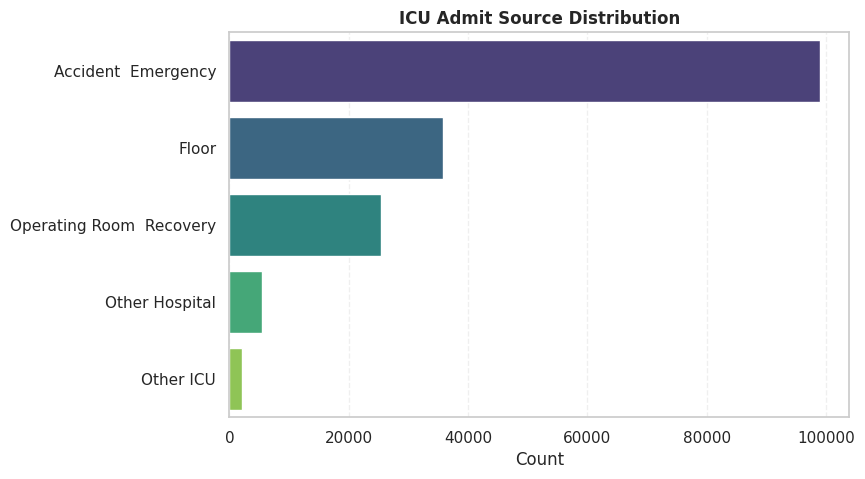

In [ ]:
data = df_imputed['icu_admit_source'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("ICU Admit Source Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_6048/1568839980.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


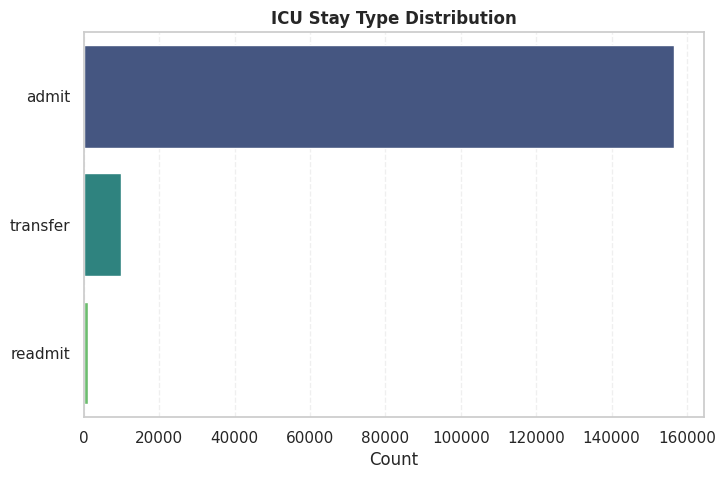

In [ ]:
data = df_imputed['icu_stay_type'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("ICU Stay Type Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_6048/1702280614.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


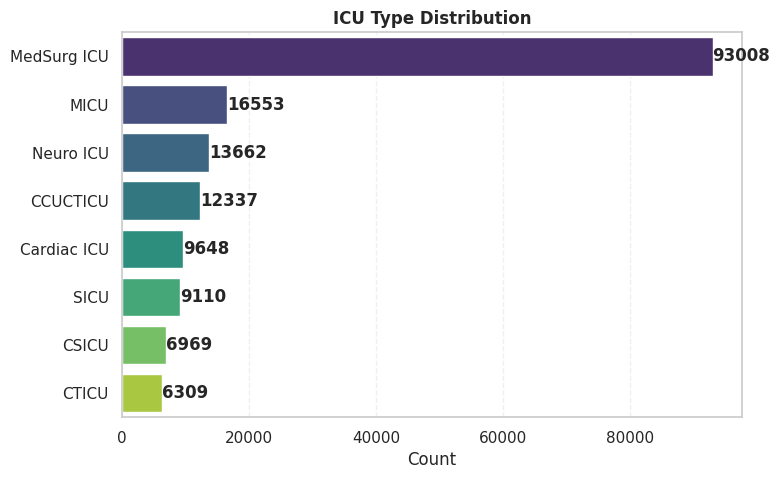

In [ ]:
data = df_imputed['icu_type'].value_counts()

plt.figure()
ax = sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

# value labels
for i, v in enumerate(data.values):
    plt.text(v, i, str(v), va='center', fontweight='bold')

plt.title("ICU Type Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_6048/1011880088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


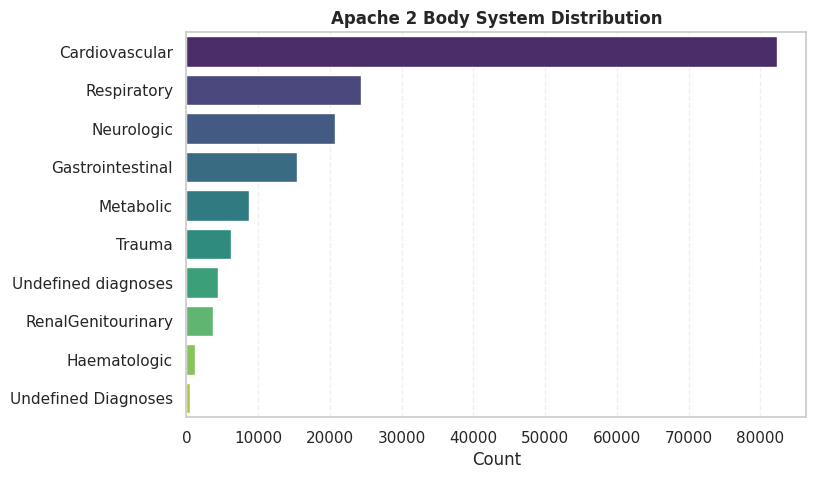

In [ ]:
data = df_imputed['apache_2_bodysystem'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("Apache 2 Body System Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_6048/3647690236.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


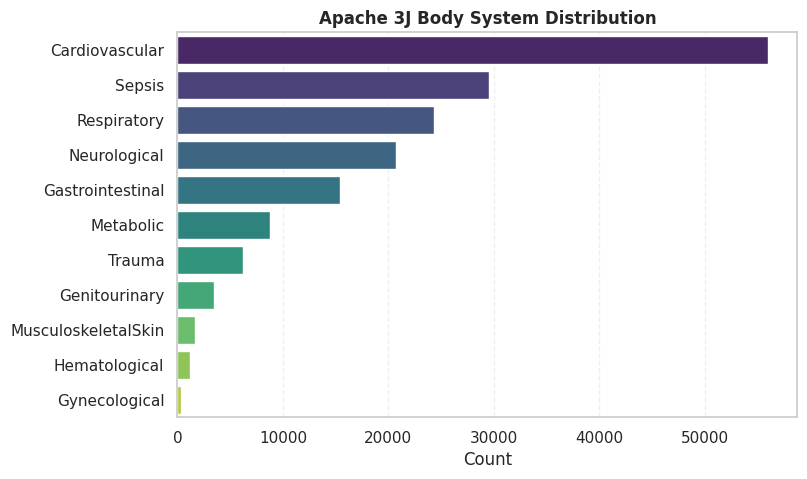

In [ ]:
data = df_imputed['apache_3j_bodysystem'].value_counts()

plt.figure()
sns.barplot(
    x=data.values,
    y=data.index,
    palette=COLOR_MAP
)

plt.title("Apache 3J Body System Distribution", fontweight='bold')
plt.xlabel("Count")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.show()

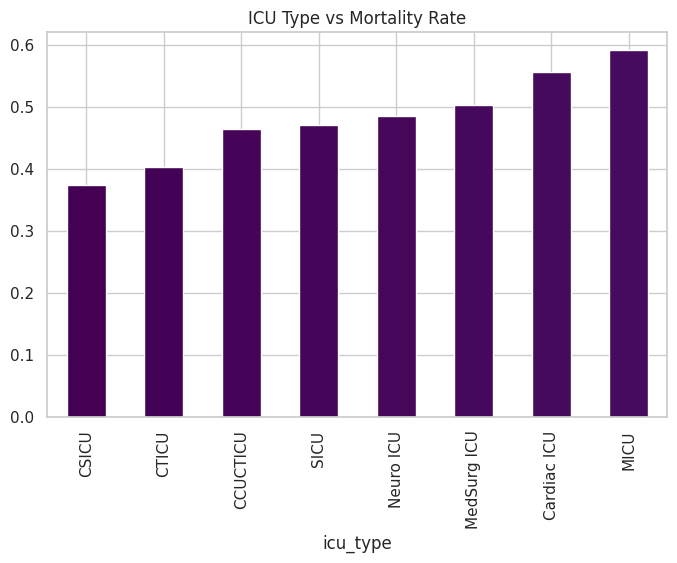

In [ ]:
df_imputed.groupby('icu_type')['hospital_death'].mean().sort_values().plot(
    kind='bar',
    color=plt.cm.viridis(range(len(df_imputed['icu_type'].unique())))
)
plt.title("ICU Type vs Mortality Rate")
plt.show()

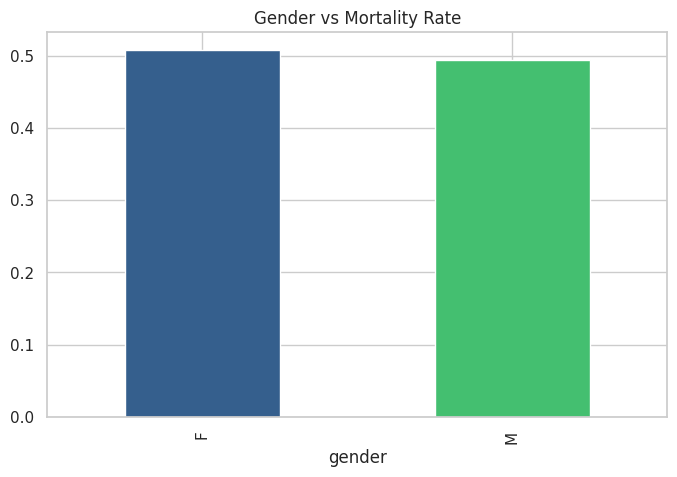

In [ ]:
df_imputed.groupby('gender')['hospital_death'].mean().plot(
    kind='bar',
    color=plt.cm.viridis([0.3, 0.7])
)
plt.title("Gender vs Mortality Rate")
plt.show()

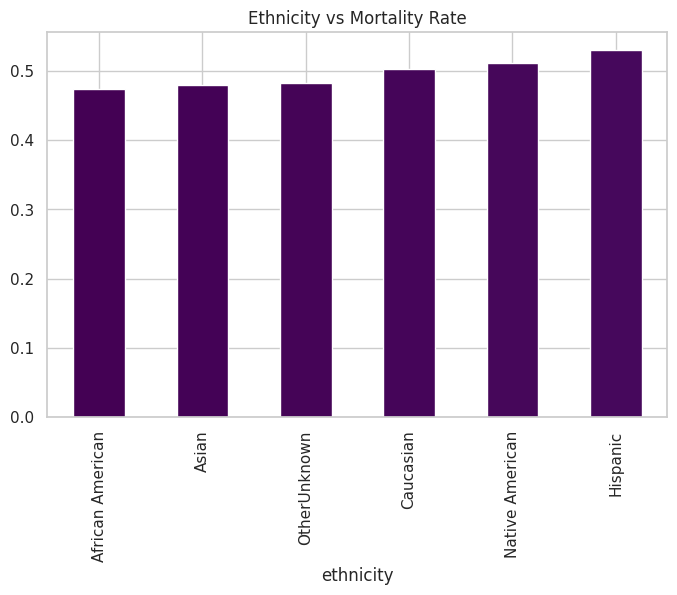

In [ ]:
df_imputed.groupby('ethnicity')['hospital_death'].mean().sort_values().plot(
    kind='bar',
    color=plt.cm.viridis(range(len(df_imputed['ethnicity'].unique())))
)
plt.title("Ethnicity vs Mortality Rate")
plt.show()

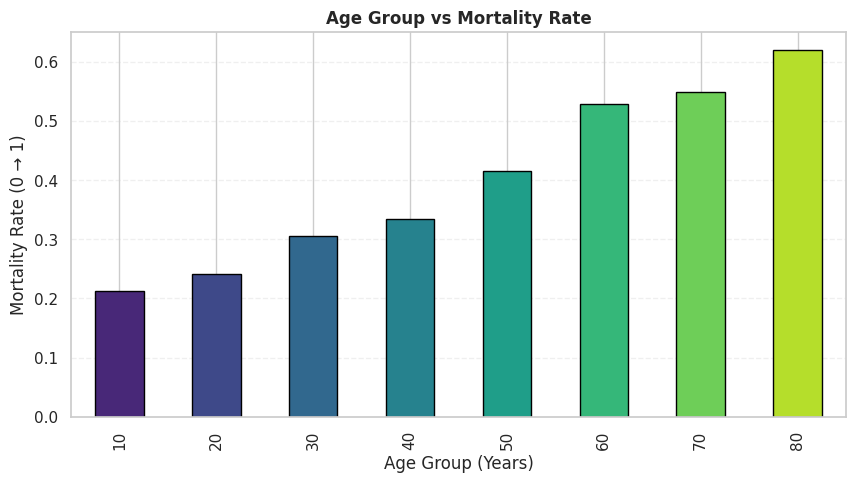

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# create clean integer age groups
df_imputed['age_group'] = (df_imputed['age'] // 10) * 10

age_mortality = df_imputed.groupby('age_group')['hospital_death'].mean()

plt.figure(figsize=(10,5))

colors = sns.color_palette("viridis", len(age_mortality))

age_mortality.plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title("Age Group vs Mortality Rate", fontweight='bold')
plt.xlabel("Age Group (Years)")
plt.ylabel("Mortality Rate (0 → 1)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

hospital_death column:
0 = patient survived
1 = patient died

In [ ]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167596 entries, 0 to 167595
Data columns (total 45 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   age                            167596 non-null  int64  
 1   ethnicity                      167596 non-null  object 
 2   gender                         167596 non-null  object 
 3   icu_admit_source               167596 non-null  object 
 4   icu_stay_type                  167596 non-null  object 
 5   icu_type                       167596 non-null  object 
 6   apache_2_diagnosis             167596 non-null  int64  
 7   apache_3j_diagnosis            167596 non-null  int64  
 8   gcs_eyes_apache                167596 non-null  int64  
 9   gcs_verbal_apache              167596 non-null  int64  
 10  heart_rate_apache              167596 non-null  int64  
 11  resprate_apache                167596 non-null  int64  
 12  temp_apache                   

In [ ]:
import pandas as pd

# separate target
target = df_imputed['hospital_death']

# categorical columns (object dtype)
cat_cols = df_imputed.select_dtypes(include=['object']).columns

# one-hot encoding
df_encoded = pd.get_dummies(df_imputed, columns=cat_cols, drop_first=False)

# add target back (if needed, usually already included)
df_encoded['hospital_death'] = target

# check result
print(df_encoded.shape)
df_encoded.head()

(167596, 83)


,age,apache_2_diagnosis,apache_3j_diagnosis,gcs_eyes_apache,gcs_verbal_apache,heart_rate_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_min,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_RenalGenitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,23,119,601,4,5,46,52,36,0.0,58,...,False,False,False,False,False,False,False,True,False,False
1,69,301,410,4,5,171,32,35,1.0,45,...,False,False,False,False,True,False,False,False,False,False
2,65,122,409,4,5,104,28,36,0.0,43,...,True,False,False,False,False,False,False,False,False,False
3,85,110,104,4,5,118,40,37,0.0,64,...,True,False,False,False,False,False,False,False,False,False
4,88,301,403,2,4,151,30,35,0.0,66,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
from google.colab import files

df_encoded.to_csv("Clean_Encoded-Data.csv", index=False)
files.download("Clean_Encoded-Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df=pd.read_csv("/content/Clean_Encoded-Data.csv")

/tmp/ipykernel_1678/2556539918.py:1: DtypeWarning: Columns (50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("/content/Clean_Encoded-Data.csv")


In [ ]:
df.head()

,age,apache_2_diagnosis,apache_3j_diagnosis,gcs_eyes_apache,gcs_verbal_apache,heart_rate_apache,resprate_apache,temp_apache,ventilated_apache,d1_diasbp_min,...,apache_2_bodysystem_Cardiovascular,apache_2_bodysystem_Gastrointestinal,apache_2_bodysystem_Haematologic,apache_2_bodysystem_Metabolic,apache_2_bodysystem_Neurologic,apache_2_bodysystem_RenalGenitourinary,apache_2_bodysystem_Respiratory,apache_2_bodysystem_Trauma,apache_2_bodysystem_Undefined Diagnoses,apache_2_bodysystem_Undefined diagnoses
0,23,119,601,4,5,46,52,36,0.0,58,...,False,False,False,False,False,False,False,True,False,False
1,69,301,410,4,5,171,32,35,1.0,45,...,False,False,False,False,True,False,False,False,False,False
2,65,122,409,4,5,104,28,36,0.0,43,...,True,False,False,False,False,False,False,False,False,False
3,85,110,104,4,5,118,40,37,0.0,64,...,True,False,False,False,False,False,False,False,False,False
4,88,301,403,2,4,151,30,35,0.0,66,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
print('hospital_death' in df.columns)

True


After SMOTE Counts:
hospital_death
0    77210
1    77210
Name: count, dtype: int64


/tmp/ipykernel_1678/3708038281.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


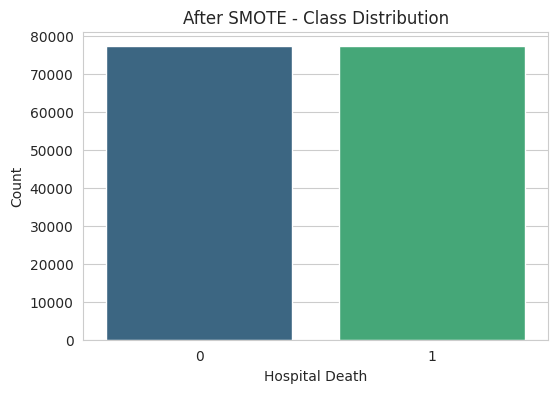

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

COLOR_MAP = "viridis"

# After SMOTE counts
after_counts = df_balanced['hospital_death'].value_counts()

print("After SMOTE Counts:")
print(after_counts)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(
    x=after_counts.index,
    y=after_counts.values,
    palette=COLOR_MAP
)

plt.title("After SMOTE - Class Distribution")
plt.xlabel("Hospital Death")
plt.ylabel("Count")
plt.show()